In [146]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [147]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from utils import decorate, underride, configure_plot_style, AIBM_COLORS, code_to_who_country

configure_plot_style()

In [148]:
def load_and_inventory(filename):
    """
    Load a WHO health indicator CSV file and print inventory information.
    
    Filters the data to include only records from year 2000 to 2019 (excludes 2020+)
    to avoid COVID-19 pandemic distortions, and country-level data (excludes regional aggregates).
    Adds a 'CountryName' column mapping country codes to country names using code_to_who_country.
    
    Parameters
    ----------
    filename : str
        Path to the CSV file containing WHO health indicator data.
        
    Returns
    -------
    df : pandas.DataFrame
        Filtered DataFrame containing country-level data from 2000-2019,
        with an additional 'CountryName' column.
    years : numpy.ndarray
        Array of unique years present in the filtered dataset.
    """
    # Filter to 2000-2019 to exclude COVID-19 pandemic years (2020+)
    df = pd.read_csv(filename).query('Year >= 2000 and Year <= 2019 and CountryCode == "COUNTRY"')
    
    # Add country name column using code_to_who_country mapping
    # The 'Country' column contains country codes (e.g., 'USA', 'GBR')
    df['CountryName'] = df['Country'].map(code_to_who_country)
    
    print(df.shape)

    try:
        print(df['IndicatorCode'].unique())
        print(df['IndicatorName'].unique())
    except KeyError:
        pass

    sexes = df['Sex'].unique()
    print(sexes)
    print(df['Comments'].unique())
    years = df['Year'].unique()
    print(years)
    print(df['Country'].unique())
    
    return df, years

In [149]:
from functools import reduce

def compute_gender_gap(df, value_col, sexes):
    """
    Return a DataFrame with separate columns for each sex and a gap column,
    handling cases where one or more sexes are missing.

    Parameters
    ----------
    df : pandas.DataFrame
        Must include 'Country', 'Year', 'Sex', and the specified value_col.
        May also include 'CountryName' which will be preserved.
    value_col : str
        Name of the column containing the numeric value to compare between sexes.
    sexes : list of str
        List of values in the 'Sex' column, e.g. ['SEX_MLE', 'SEX_FMLE'].
        The first two entries are used to compute the gap (second - first).

    Returns
    -------
    df_by_sex : pandas.DataFrame
        Contains columns for each available sex and a gap column (second - first)
        if both sexes are present. Also includes 'CountryName' (added via mapping) and 'Year'.
    """
    # Determine which columns to keep
    # Base columns: Country, Year, and the value column (which will be renamed)
    # CountryName will be added later via mapping
    base_cols = ['Country', 'Year']
    
    dfs = []

    # Build a renamed DataFrame for each sex, only if it exists
    # Select only the columns we want to keep before merging
    for sex in sexes:
        temp = df[df['Sex'] == sex]
        if not temp.empty:
            # Select only the columns we need: base columns + value column
            cols_to_select = base_cols + [value_col]
            temp = temp[cols_to_select].copy()
            # Rename the value column to include the sex
            temp = temp.rename(columns={value_col: f"{value_col}_{sex}"})
            dfs.append(temp)

    # If no data at all, return empty DataFrame
    if not dfs:
        return pd.DataFrame(columns=['Country', 'Year'])

    # Merge all available sexes
    merge_on = ['Country', 'Year']
    df_by_sex = reduce(lambda left, right: left.merge(right, on=merge_on, how='outer'), dfs)

    # Compute the gap only if both sexes are available
    if len(sexes) >= 2:
        col1 = f"{value_col}_{sexes[0]}"
        col2 = f"{value_col}_{sexes[1]}"
        if col1 in df_by_sex.columns and col2 in df_by_sex.columns:
            df_by_sex[f"{value_col}_Gap"] = df_by_sex[col2] - df_by_sex[col1]

    df_by_sex['CountryName'] = df_by_sex['Country'].map(code_to_who_country)

    return df_by_sex


In [150]:
def summarize_gap(df, col, sexes=None):
    """
    Compute gender gap and create summary visualization using most recent data per country.
    
    Computes gender gaps using compute_gender_gap, then selects the most recent year
    available for each country (which may differ by country). Creates a scatter plot
    comparing values between sexes (if multiple sexes are provided).
    
    Parameters
    ----------
    df : pandas.DataFrame
        DataFrame containing health indicator data with 'Country', 'Year', 'Sex',
        and the value column specified by col. May also include 'CountryName'.
    col : str
        Name of the column containing the numeric value to compare between sexes.
    sexes : list of str
        List of sex values to compare (e.g., ['Male', 'Female']).
        
    Returns
    -------
    df_gap : pandas.DataFrame
        DataFrame with gender gap computed for all years. Includes 'CountryName' and 'Year' columns.
    df_recent : pandas.DataFrame
        DataFrame with the most recent available year for each country, indexed by Country.
        Includes 'CountryName' and 'Year' columns.
    """
    sexes = sexes or ['Male', 'Female']
    df_gap = compute_gender_gap(df, col, sexes)
    
    # Get the most recent year for each country
    most_recent_years = df_gap.groupby('Country')['Year'].max().reset_index()
    df_recent = df_gap.merge(most_recent_years, on=['Country', 'Year'])
    
    # Set index to Country, but keep CountryName and Year as columns
    df_recent = df_recent.set_index('Country')
    
    if len(sexes) > 1:
        cols = [f'{col}_{sex}' for sex in sexes]
        high = df_recent[cols].max().max()
        domain = [0, high]
        scatter_plot(df_recent, cols, domain)
        decorate(xlabel=f'{col}, Male', 
                 ylabel=f'{col}, Female', title=f'All Countries')
    
    return df_gap, df_recent

In [151]:
def scatter_plot(df, cols, domain, **options):
    """
    Create a scatter plot comparing two columns with a diagonal reference line.
    
    Plots the values from two columns against each other, with a diagonal
    reference line (y=x) to show equality. Uses a square aspect ratio by default.
    
    Parameters
    ----------
    df : pandas.DataFrame
        DataFrame indexed by country, containing the columns to plot.
    cols : list of str
        List of two column names to plot on x and y axes.
    domain : list of float
        Two-element list [min, max] defining the plot domain for both axes.
    **options : dict
        Additional keyword arguments passed to decorate() for plot customization
        (e.g., xlabel, ylabel, title).
    """
    plt.plot(df[cols[0]], df[cols[1]], '.', color=AIBM_COLORS['crimson'])
    plt.plot(domain, domain, color='gray', alpha=0.5)
    
    underride(options, aspect='equal')
    decorate(**options)

In [152]:
from utils import oecd_codes

def get_oecd(df):
    """
    Filter DataFrame to include only OECD member countries.
    
    Parameters
    ----------
    df : pandas.DataFrame
        DataFrame indexed by country codes.
        
    Returns
    -------
    pandas.DataFrame
        Subset of the input DataFrame containing only OECD countries.
        
    Note
    -----
    Does not warn if any expected OECD countries are missing from the data.
    """
    # TODO: Warn if any are missing
    return df.loc[df.index.intersection(oecd_codes)]

In [153]:
from empiricaldist import Cdf

def plot_cdfs(df, label='', **options):
    """
    Plot cumulative distribution functions (CDFs) for columns ending in 'ale'.
    
    Creates CDF plots for all columns in the DataFrame that end with 'ale'
    (typically 'Male' and 'Female' columns). Each CDF is plotted with a label
    combining the column name and the provided label.
    
    Parameters
    ----------
    df : pandas.DataFrame
        DataFrame containing numeric columns to plot as CDFs.
    label : str, optional
        Additional label text to append to each CDF plot label (default: '').
    **options : dict
        Additional keyword arguments for plot customization.
    """
    cols = [col for col in df.columns if col.endswith('ale')]
    for col in cols:
        vals = df[col].dropna()
        if vals.count() == 0:
            break
        cdf = Cdf.from_seq(df[col])
        cdf.plot(label=f'{col} {label}', **options)
        underride(options)

In [154]:
def plot_distributions(recent, **options):
    """
    Plot CDFs comparing all countries vs OECD countries.
    
    Creates cumulative distribution function plots for both all countries
    and OECD countries subset, allowing comparison of distributions.
    
    Parameters
    ----------
    recent : pandas.DataFrame
        DataFrame indexed by country codes, containing columns ending in 'ale'
        (typically 'Male' and 'Female' columns).
    **options : dict
        Additional keyword arguments passed to decorate() for plot customization
        (e.g., xlabel, title). The ylabel is automatically set to 'CDF'.
    """
    plot_cdfs(recent, label='All countries')
    plot_cdfs(get_oecd(recent), label='OECD')
    
    underride(options, ylabel='CDF')
    decorate(**options)

## WHO HALE data

**Healthy Life Expectancy (HALE) at birth** - The average number of years that a person can expect to live in "full health" by taking into account years lived in less than full health due to disease and/or injury. This is the **target variable** for the analysis. The gender gap (Female HALE - Male HALE) measures the difference in healthy life expectancy between women and men.

**Indicator Code**: WHOSIS_000002  
**Relevance**: Direct measure of the outcome we're trying to explain. Gender differences in HALE reflect the cumulative impact of all mortality and morbidity factors that differentially affect men and women.

Downloaded using the GHO OData API (who_data.py)

https://www.who.int/data/gho/info/gho-odata-api

In [155]:
filename = '../data/who_hale_data.csv'
hale, years = load_and_inventory(filename)

(11100, 10)
['SEX_BTSX' 'SEX_FMLE' 'SEX_MLE']
[nan]
[2000 2001 2002 2003 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013
 2014 2015 2016 2017 2018 2019]
['AFG' 'AGO' 'ALB' 'ARE' 'ARG' 'ARM' 'ATG' 'AUS' 'AUT' 'AZE' 'BDI' 'BEL'
 'BEN' 'BFA' 'BGD' 'BGR' 'BHR' 'BHS' 'BIH' 'BLR' 'BLZ' 'BOL' 'BRA' 'BRB'
 'BRN' 'BTN' 'BWA' 'CAF' 'CAN' 'CHE' 'CHL' 'CHN' 'CIV' 'CMR' 'COD' 'COG'
 'COL' 'COM' 'CPV' 'CRI' 'CUB' 'CYP' 'CZE' 'DEU' 'DJI' 'DNK' 'DOM' 'DZA'
 'ECU' 'EGY' 'ERI' 'ESP' 'EST' 'ETH' 'FIN' 'FJI' 'FRA' 'FSM' 'GAB' 'GBR'
 'GEO' 'GHA' 'GIN' 'GMB' 'GNB' 'GNQ' 'GRC' 'GRD' 'GTM' 'GUY' 'HND' 'HRV'
 'HTI' 'HUN' 'IDN' 'IND' 'IRL' 'IRN' 'IRQ' 'ISL' 'ISR' 'ITA' 'JAM' 'JOR'
 'JPN' 'KAZ' 'KEN' 'KGZ' 'KHM' 'KIR' 'KOR' 'KWT' 'LAO' 'LBN' 'LBR' 'LBY'
 'LCA' 'LKA' 'LSO' 'LTU' 'LUX' 'LVA' 'MAR' 'MDA' 'MDG' 'MDV' 'MEX' 'MKD'
 'MLI' 'MLT' 'MMR' 'MNE' 'MNG' 'MOZ' 'MRT' 'MUS' 'MWI' 'MYS' 'NAM' 'NER'
 'NGA' 'NIC' 'NLD' 'NOR' 'NPL' 'NZL' 'OMN' 'PAK' 'PAN' 'PER' 'PHL' 'PNG'
 'POL' 'PRI' 'PRK' 'PRT' 'PRY' 'PSE' 'QAT'

In [156]:
d = {'SEX_BTSX': 'Both', 'SEX_FMLE': 'Female', 'SEX_MLE': 'Male', }
hale['Sex'] = hale['Sex'].replace(d)

In [157]:
hale.head()

,Country,CountryCode,Year,Sex,HALE_Years,HALE_Low,HALE_High,Comments,DataSource,CountryName
0,AFG,COUNTRY,2000,Both,46.027950,44.939602,47.308578,NaN,NaN,Afghanistan
1,AFG,COUNTRY,2001,Both,46.116121,44.907570,47.033098,NaN,NaN,Afghanistan
2,AFG,COUNTRY,2002,Both,47.184852,46.147952,48.308520,NaN,NaN,Afghanistan
3,AFG,COUNTRY,2003,Both,47.977953,47.016452,48.976006,NaN,NaN,Afghanistan
4,AFG,COUNTRY,2004,Both,48.324761,47.311935,49.325042,NaN,NaN,Afghanistan


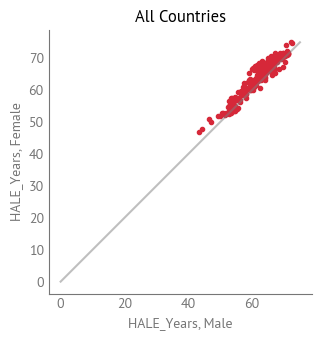

In [158]:
col = 'HALE_Years'
year = years[-1]
hale_gap, hale_recent = summarize_gap(hale, col)

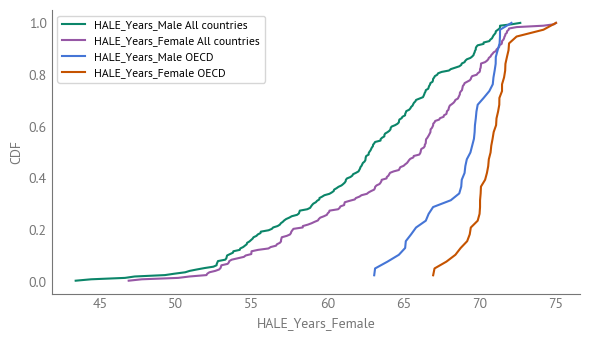

In [159]:
plot_distributions(hale_recent)

## Smoking

**Age-standardized current tobacco smoking prevalence (%)** - Percentage of population aged 15+ who currently smoke any tobacco product, age-standardized for cross-country comparison.

**Indicator Code**: M_Est_smk_curr_std  
**Relevance**: Historically, men have had significantly higher smoking rates than women. Smoking is a major contributor to cardiovascular disease, lung cancer, and respiratory diseases. As smoking rates have converged between genders in some countries, the life expectancy gap has narrowed, suggesting smoking is one of the most important modifiable factors contributing to the HALE gender gap.

In [160]:
filename = '../data/who_smoking_data.csv'
smoking, years = load_and_inventory(filename)

(2475, 12)
['M_Est_smk_curr_std']
['Age-standardized current tobacco smoking prevalence']
['Both sexes' 'Female' 'Male']
[nan 'The most recent survey was conducted in 2013. This is a projection.'
 'The most recent survey was conducted in 2011-12. This is a projection.'
 'The most recent survey was conducted in 2012. This is a projection.'
 'The most recent survey was conducted in 2014. This is a projection.']
[2000 2005 2007 2010 2015]
['AFG' 'ALB' 'AND' 'ARE' 'ARG' 'ARM' 'AUS' 'AUT' 'AZE' 'BDI' 'BEL' 'BEN'
 'BFA' 'BGD' 'BGR' 'BHR' 'BHS' 'BIH' 'BLR' 'BLZ' 'BOL' 'BRA' 'BRB' 'BRN'
 'BTN' 'BWA' 'CAN' 'CHE' 'CHL' 'CHN' 'CIV' 'CMR' 'COD' 'COG' 'COK' 'COL'
 'COM' 'CPV' 'CRI' 'CUB' 'CYP' 'CZE' 'DEU' 'DNK' 'DOM' 'DZA' 'ECU' 'EGY'
 'ESP' 'EST' 'ETH' 'FIN' 'FJI' 'FRA' 'GBR' 'GEO' 'GHA' 'GMB' 'GNB' 'GRC'
 'GTM' 'GUY' 'HND' 'HRV' 'HTI' 'HUN' 'IDN' 'IND' 'IRL' 'IRN' 'IRQ' 'ISL'
 'ISR' 'ITA' 'JAM' 'JOR' 'JPN' 'KAZ' 'KEN' 'KGZ' 'KHM' 'KIR' 'KOR' 'KWT'
 'LAO' 'LBN' 'LBR' 'LCA' 'LKA' 'LSO' 'LTU' 'LUX' 

In [161]:
smoking.head()

,IndicatorCode,IndicatorName,Country,CountryCode,Year,Sex,SmokingPrevalence,SmokingPrevalence_Low,SmokingPrevalence_High,Comments,DataSource,CountryName
0,M_Est_smk_curr_std,Age-standardized current tobacco smoking preva...,AFG,COUNTRY,2000,Both sexes,22.5,10.5,34.4,NaN,NaN,Afghanistan
1,M_Est_smk_curr_std,Age-standardized current tobacco smoking preva...,AFG,COUNTRY,2005,Both sexes,17.9,9.6,26.3,NaN,NaN,Afghanistan
2,M_Est_smk_curr_std,Age-standardized current tobacco smoking preva...,AFG,COUNTRY,2007,Both sexes,16.3,9.4,23.3,NaN,NaN,Afghanistan
3,M_Est_smk_curr_std,Age-standardized current tobacco smoking preva...,AFG,COUNTRY,2010,Both sexes,14.5,9.6,19.4,NaN,NaN,Afghanistan
4,M_Est_smk_curr_std,Age-standardized current tobacco smoking preva...,AFG,COUNTRY,2015,Both sexes,11.8,8.0,15.6,NaN,NaN,Afghanistan


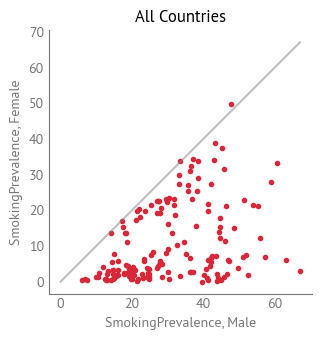

In [162]:
col = 'SmokingPrevalence'
year = years[-1]
smoking_gap, smoking_recent = summarize_gap(smoking, col)

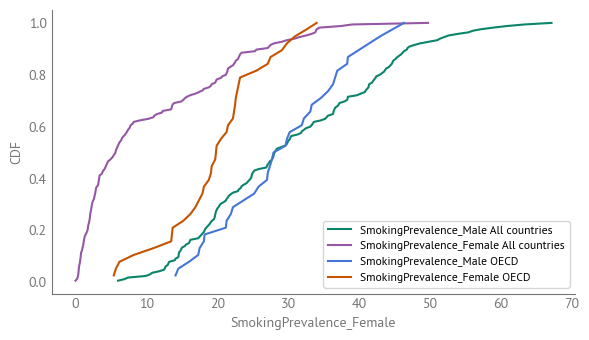

In [163]:
plot_distributions(smoking_recent)

## Suicide

**Age-standardized suicide rates (per 100,000 population)** - Deaths from intentional self-harm, age-standardized for cross-country comparison.

**Indicator Code**: MH_12  
**Relevance**: Suicide rates are typically higher in men across most countries, directly contributing to the gender gap in mortality. Suicide reflects mental health and social factors that differentially affect men and women, and is strongly linked to mortality.

In [164]:
filename = '../data/who_suicide_rates.csv'
suicide, years = load_and_inventory(filename)

(11100, 12)
['MH_12']
['Age-standardized suicide rates (per 100 000 population)']
['Both sexes' 'Female' 'Male']
[nan]
[2000 2001 2002 2003 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013
 2014 2015 2016 2017 2018 2019]
['AFG' 'AGO' 'ALB' 'ARE' 'ARG' 'ARM' 'ATG' 'AUS' 'AUT' 'AZE' 'BDI' 'BEL'
 'BEN' 'BFA' 'BGD' 'BGR' 'BHR' 'BHS' 'BIH' 'BLR' 'BLZ' 'BOL' 'BRA' 'BRB'
 'BRN' 'BTN' 'BWA' 'CAF' 'CAN' 'CHE' 'CHL' 'CHN' 'CIV' 'CMR' 'COD' 'COG'
 'COL' 'COM' 'CPV' 'CRI' 'CUB' 'CYP' 'CZE' 'DEU' 'DJI' 'DNK' 'DOM' 'DZA'
 'ECU' 'EGY' 'ERI' 'ESP' 'EST' 'ETH' 'FIN' 'FJI' 'FRA' 'FSM' 'GAB' 'GBR'
 'GEO' 'GHA' 'GIN' 'GMB' 'GNB' 'GNQ' 'GRC' 'GRD' 'GTM' 'GUY' 'HND' 'HRV'
 'HTI' 'HUN' 'IDN' 'IND' 'IRL' 'IRN' 'IRQ' 'ISL' 'ISR' 'ITA' 'JAM' 'JOR'
 'JPN' 'KAZ' 'KEN' 'KGZ' 'KHM' 'KIR' 'KOR' 'KWT' 'LAO' 'LBN' 'LBR' 'LBY'
 'LCA' 'LKA' 'LSO' 'LTU' 'LUX' 'LVA' 'MAR' 'MDA' 'MDG' 'MDV' 'MEX' 'MKD'
 'MLI' 'MLT' 'MMR' 'MNE' 'MNG' 'MOZ' 'MRT' 'MUS' 'MWI' 'MYS' 'NAM' 'NER'
 'NGA' 'NIC' 'NLD' 'NOR' 'NPL' 'NZL' 'OMN' 'PAK'

In [165]:
suicide.head()

,IndicatorCode,IndicatorName,Country,CountryCode,Year,Sex,SuicideRate,SuicideRate_Low,SuicideRate_High,Comments,DataSource,CountryName
0,MH_12,Age-standardized suicide rates (per 100 000 po...,AFG,COUNTRY,2000,Both sexes,7.185717,3.764944,12.084243,NaN,NaN,Afghanistan
1,MH_12,Age-standardized suicide rates (per 100 000 po...,AFG,COUNTRY,2001,Both sexes,7.270323,3.817979,12.215665,NaN,NaN,Afghanistan
2,MH_12,Age-standardized suicide rates (per 100 000 po...,AFG,COUNTRY,2002,Both sexes,7.112670,3.821785,11.814730,NaN,NaN,Afghanistan
3,MH_12,Age-standardized suicide rates (per 100 000 po...,AFG,COUNTRY,2003,Both sexes,7.043811,3.856506,12.002093,NaN,NaN,Afghanistan
4,MH_12,Age-standardized suicide rates (per 100 000 po...,AFG,COUNTRY,2004,Both sexes,7.025987,3.889151,12.129586,NaN,NaN,Afghanistan


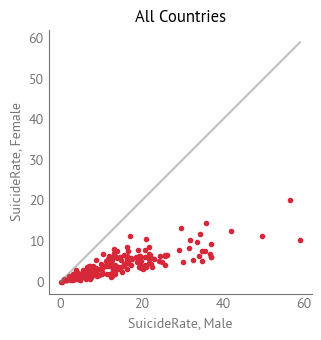

In [166]:
col = 'SuicideRate'
year = years[-1]
suicide_gap, suicide_recent = summarize_gap(suicide, col)

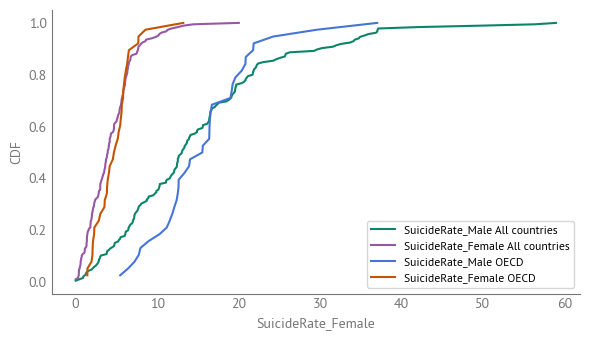

In [167]:
plot_distributions(suicide_recent)

## Alcohol

**Alcohol-attributable all-cause deaths per 100,000 (age-standardized)** - Deaths from all causes that are attributable to alcohol consumption, including direct alcohol-related deaths and alcohol-attributable deaths from other causes (e.g., accidents, liver disease).

**Indicator Code**: SA_0000001832  
**Relevance**: Men typically have higher rates of alcohol consumption and alcohol-related diseases. Alcohol contributes to liver disease, accidents, and various health conditions, directly impacting mortality. Age-standardized rates match HALE methodology for cross-country comparison.

In [168]:
filename = '../data/who_alcohol_death_rates.csv'
alcohol, years = load_and_inventory(filename)

(540, 12)
['SA_0000001832']
['Alcohol-attributable all-cause deaths per 100,000, age standardized']
['Both sexes' 'Female' 'Male']
[nan]
[2019]
['AFG' 'AGO' 'ALB' 'ARE' 'ARG' 'ARM' 'ATG' 'AUS' 'AUT' 'AZE' 'BDI' 'BEL'
 'BEN' 'BFA' 'BGD' 'BGR' 'BHR' 'BHS' 'BIH' 'BLR' 'BLZ' 'BOL' 'BRA' 'BRB'
 'BRN' 'BTN' 'BWA' 'CAF' 'CAN' 'CHE' 'CHL' 'CHN' 'CIV' 'CMR' 'COD' 'COG'
 'COL' 'COM' 'CPV' 'CRI' 'CUB' 'CYP' 'CZE' 'DEU' 'DJI' 'DNK' 'DOM' 'DZA'
 'ECU' 'EGY' 'ERI' 'ESP' 'EST' 'ETH' 'FIN' 'FJI' 'FRA' 'FSM' 'GAB' 'GBR'
 'GEO' 'GHA' 'GIN' 'GMB' 'GNB' 'GNQ' 'GRC' 'GRD' 'GTM' 'GUY' 'HND' 'HRV'
 'HTI' 'HUN' 'IDN' 'IND' 'IRL' 'IRN' 'IRQ' 'ISL' 'ISR' 'ITA' 'JAM' 'JOR'
 'JPN' 'KAZ' 'KEN' 'KGZ' 'KHM' 'KIR' 'KOR' 'KWT' 'LAO' 'LBN' 'LBR' 'LBY'
 'LCA' 'LKA' 'LSO' 'LTU' 'LUX' 'LVA' 'MAR' 'MDA' 'MDG' 'MDV' 'MEX' 'MKD'
 'MLI' 'MLT' 'MMR' 'MNG' 'MOZ' 'MRT' 'MUS' 'MWI' 'MYS' 'NAM' 'NER' 'NGA'
 'NIC' 'NLD' 'NOR' 'NPL' 'NZL' 'OMN' 'PAK' 'PAN' 'PER' 'PHL' 'PNG' 'POL'
 'PRK' 'PRT' 'PRY' 'QAT' 'ROU' 'RUS' 'RWA' 'SAU' 'SDN

In [169]:
alcohol.head()

,IndicatorCode,IndicatorName,Country,CountryCode,Year,Sex,AlcoholDeathRate,AlcoholDeathRate_Low,AlcoholDeathRate_High,Comments,DataSource,CountryName
0,SA_0000001832,"Alcohol-attributable all-cause deaths per 100,...",AFG,COUNTRY,2019,Both sexes,4.949863,4.002665,6.983689,NaN,NaN,Afghanistan
1,SA_0000001832,"Alcohol-attributable all-cause deaths per 100,...",AFG,COUNTRY,2019,Female,4.002300,2.527392,6.215428,NaN,NaN,Afghanistan
2,SA_0000001832,"Alcohol-attributable all-cause deaths per 100,...",AFG,COUNTRY,2019,Male,5.914343,4.479561,9.296961,NaN,NaN,Afghanistan
3,SA_0000001832,"Alcohol-attributable all-cause deaths per 100,...",AGO,COUNTRY,2019,Both sexes,88.707178,63.949144,114.463780,NaN,NaN,Angola
4,SA_0000001832,"Alcohol-attributable all-cause deaths per 100,...",AGO,COUNTRY,2019,Female,34.885563,26.543712,47.578170,NaN,NaN,Angola


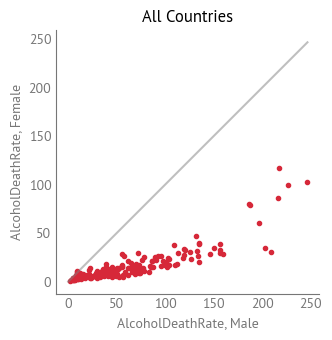

In [170]:
col = 'AlcoholDeathRate'
year = years[-1]
alcohol_gap, alcohol_recent = summarize_gap(alcohol, col)

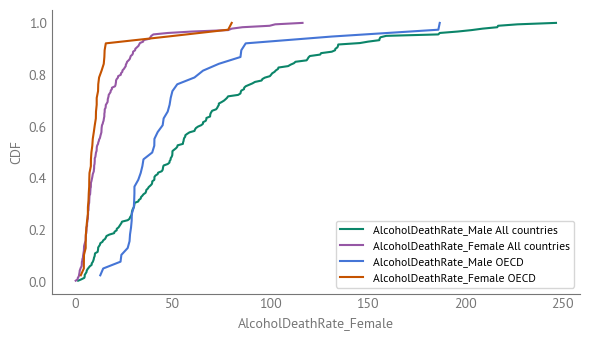

In [171]:
plot_distributions(alcohol_recent)

## Poison

**Mortality rate attributed to unintentional poisoning (per 100,000 population)** - Deaths from accidental poisonings from chemicals, drugs, and other substances.

**Indicator Code**: SDGPOISON  
**Relevance**: Men often have higher rates of accidental deaths, including poisonings. This reflects occupational hazards and risk-taking behaviors that contribute to the gender gap in mortality. Has excellent temporal coverage (2000-2021) and country coverage (196 countries).

In [172]:
filename = '../data/who_poisoning_rates.csv'
poison, years = load_and_inventory(filename)

(11100, 12)
['SDGPOISON']
['Mortality rate attributed to unintentional poisoning (per 100 000 population)']
['Both sexes' 'Female' 'Male']
[nan]
[2000 2001 2002 2003 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013
 2014 2015 2016 2017 2018 2019]
['AFG' 'AGO' 'ALB' 'ARE' 'ARG' 'ARM' 'ATG' 'AUS' 'AUT' 'AZE' 'BDI' 'BEL'
 'BEN' 'BFA' 'BGD' 'BGR' 'BHR' 'BHS' 'BIH' 'BLR' 'BLZ' 'BOL' 'BRA' 'BRB'
 'BRN' 'BTN' 'BWA' 'CAF' 'CAN' 'CHE' 'CHL' 'CHN' 'CIV' 'CMR' 'COD' 'COG'
 'COL' 'COM' 'CPV' 'CRI' 'CUB' 'CYP' 'CZE' 'DEU' 'DJI' 'DNK' 'DOM' 'DZA'
 'ECU' 'EGY' 'ERI' 'ESP' 'EST' 'ETH' 'FIN' 'FJI' 'FRA' 'FSM' 'GAB' 'GBR'
 'GEO' 'GHA' 'GIN' 'GMB' 'GNB' 'GNQ' 'GRC' 'GRD' 'GTM' 'GUY' 'HND' 'HRV'
 'HTI' 'HUN' 'IDN' 'IND' 'IRL' 'IRN' 'IRQ' 'ISL' 'ISR' 'ITA' 'JAM' 'JOR'
 'JPN' 'KAZ' 'KEN' 'KGZ' 'KHM' 'KIR' 'KOR' 'KWT' 'LAO' 'LBN' 'LBR' 'LBY'
 'LCA' 'LKA' 'LSO' 'LTU' 'LUX' 'LVA' 'MAR' 'MDA' 'MDG' 'MDV' 'MEX' 'MKD'
 'MLI' 'MLT' 'MMR' 'MNE' 'MNG' 'MOZ' 'MRT' 'MUS' 'MWI' 'MYS' 'NAM' 'NER'
 'NGA' 'NIC' 'NLD' 'NO

In [173]:
poison.head()

,IndicatorCode,IndicatorName,Country,CountryCode,Year,Sex,PoisoningRate,PoisoningRate_Low,PoisoningRate_High,Comments,DataSource,CountryName
0,SDGPOISON,Mortality rate attributed to unintentional poi...,AFG,COUNTRY,2000,Both sexes,3.272761,1.091069,6.816218,NaN,NaN,Afghanistan
1,SDGPOISON,Mortality rate attributed to unintentional poi...,AFG,COUNTRY,2001,Both sexes,3.351724,1.157869,6.926548,NaN,NaN,Afghanistan
2,SDGPOISON,Mortality rate attributed to unintentional poi...,AFG,COUNTRY,2002,Both sexes,3.038659,0.946774,6.704357,NaN,NaN,Afghanistan
3,SDGPOISON,Mortality rate attributed to unintentional poi...,AFG,COUNTRY,2003,Both sexes,3.689834,1.521052,7.401055,NaN,NaN,Afghanistan
4,SDGPOISON,Mortality rate attributed to unintentional poi...,AFG,COUNTRY,2004,Both sexes,3.681742,1.573983,7.347575,NaN,NaN,Afghanistan


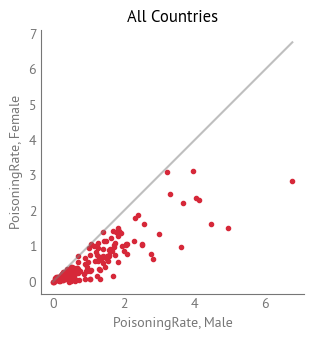

In [174]:
col = 'PoisoningRate'
year = years[-1]
poison_gap, poison_recent = summarize_gap(poison, col)

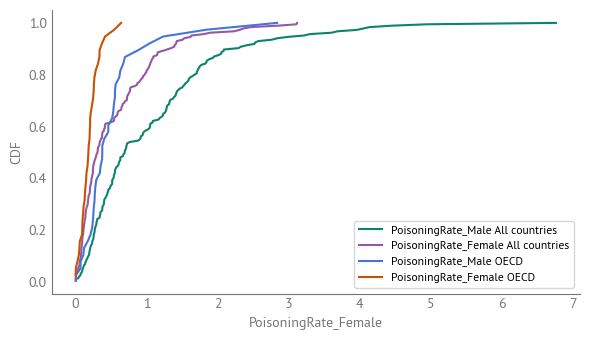

In [175]:
plot_distributions(poison_recent)

## Traffic

**Road traffic crash deaths, age-standardized death rates (15+), per 100,000 population** - Deaths from road traffic accidents, age-standardized for ages 15+.

**Indicator Code**: SA_0000001459  
**Relevance**: Road traffic deaths are typically 2-4 times higher in men across most countries, making it a major contributor to the gender gap in mortality. Reflects higher exposure to driving (including occupational exposure), occupational hazards, and potentially risk-taking behaviors. Age-standardized rates for ages 15+ match HALE methodology.

In [176]:
filename = '../data/who_road_traffic_death_rates.csv'
traffic, years = load_and_inventory(filename)

(540, 12)
['SA_0000001459']
['Road traffic crash deaths, age-standardized death rates (all ages), per 100,000 population']
['Both sexes' 'Female' 'Male']
[nan]
[2019]
['AFG' 'AGO' 'ALB' 'ARE' 'ARG' 'ARM' 'ATG' 'AUS' 'AUT' 'AZE' 'BDI' 'BEL'
 'BEN' 'BFA' 'BGD' 'BGR' 'BHR' 'BHS' 'BIH' 'BLR' 'BLZ' 'BOL' 'BRA' 'BRB'
 'BRN' 'BTN' 'BWA' 'CAF' 'CAN' 'CHE' 'CHL' 'CHN' 'CIV' 'CMR' 'COD' 'COG'
 'COL' 'COM' 'CPV' 'CRI' 'CUB' 'CYP' 'CZE' 'DEU' 'DJI' 'DNK' 'DOM' 'DZA'
 'ECU' 'EGY' 'ERI' 'ESP' 'EST' 'ETH' 'FIN' 'FJI' 'FRA' 'FSM' 'GAB' 'GBR'
 'GEO' 'GHA' 'GIN' 'GMB' 'GNB' 'GNQ' 'GRC' 'GRD' 'GTM' 'GUY' 'HND' 'HRV'
 'HTI' 'HUN' 'IDN' 'IND' 'IRL' 'IRN' 'IRQ' 'ISL' 'ISR' 'ITA' 'JAM' 'JOR'
 'JPN' 'KAZ' 'KEN' 'KGZ' 'KHM' 'KIR' 'KOR' 'KWT' 'LAO' 'LBN' 'LBR' 'LBY'
 'LCA' 'LKA' 'LSO' 'LTU' 'LUX' 'LVA' 'MAR' 'MDA' 'MDG' 'MDV' 'MEX' 'MKD'
 'MLI' 'MLT' 'MMR' 'MNG' 'MOZ' 'MRT' 'MUS' 'MWI' 'MYS' 'NAM' 'NER' 'NGA'
 'NIC' 'NLD' 'NOR' 'NPL' 'NZL' 'OMN' 'PAK' 'PAN' 'PER' 'PHL' 'PNG' 'POL'
 'PRK' 'PRT' 'PRY' 'QAT' 'ROU'

In [177]:
traffic.head()

,IndicatorCode,IndicatorName,Country,CountryCode,Year,Sex,RoadTrafficDeathRate,RoadTrafficDeathRate_Low,RoadTrafficDeathRate_High,Comments,DataSource,CountryName
0,SA_0000001459,"Road traffic crash deaths, age-standardized de...",AFG,COUNTRY,2019,Both sexes,19.806936,NaN,NaN,NaN,NaN,Afghanistan
1,SA_0000001459,"Road traffic crash deaths, age-standardized de...",AFG,COUNTRY,2019,Female,8.323253,NaN,NaN,NaN,NaN,Afghanistan
2,SA_0000001459,"Road traffic crash deaths, age-standardized de...",AFG,COUNTRY,2019,Male,30.823815,NaN,NaN,NaN,NaN,Afghanistan
3,SA_0000001459,"Road traffic crash deaths, age-standardized de...",AGO,COUNTRY,2019,Both sexes,30.060828,NaN,NaN,NaN,NaN,Angola
4,SA_0000001459,"Road traffic crash deaths, age-standardized de...",AGO,COUNTRY,2019,Female,18.692964,NaN,NaN,NaN,NaN,Angola


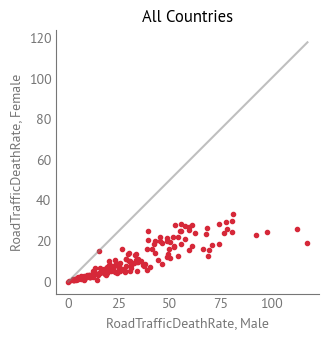

In [178]:
col = 'RoadTrafficDeathRate'
year = years[-1]
traffic_gap, traffic_recent = summarize_gap(traffic, col)

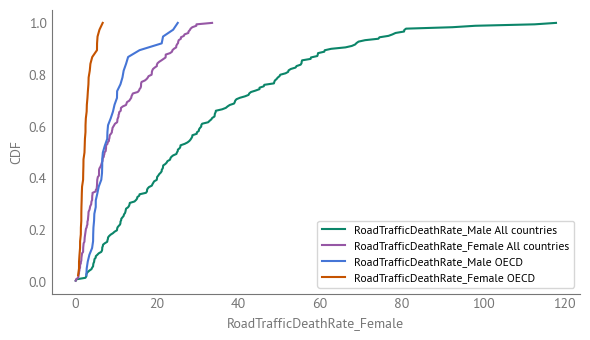

In [179]:
plot_distributions(traffic_recent)

## Maternal mortality

**Maternal mortality ratio (per 100,000 live births)** - Deaths of women during pregnancy, childbirth, or within 42 days of termination of pregnancy, per 100,000 live births.

**Indicator Code**: MDG_0000000026  
**Relevance**: Critical for understanding cases where the HALE gender gap is small due to high female mortality, especially in lower-income countries. High maternal mortality can significantly reduce the HALE gender gap by lowering female life expectancy. Inherently female-specific, so only female values are used in analysis.

In [180]:
filename = '../data/who_maternal_mortality_ratio.csv'
maternal, years = load_and_inventory(filename)

(3900, 12)
['MDG_0000000026']
['Maternal mortality ratio (per 100 000 live births)']
['Female']
[nan]
[2000 2001 2002 2003 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013
 2014 2015 2016 2017 2018 2019]
['AFG' 'AGO' 'ALB' 'AND' 'ARE' 'ARG' 'ARM' 'ATG' 'AUS' 'AUT' 'AZE' 'BDI'
 'BEL' 'BEN' 'BFA' 'BGD' 'BGR' 'BHR' 'BHS' 'BIH' 'BLR' 'BLZ' 'BOL' 'BRA'
 'BRB' 'BRN' 'BTN' 'BWA' 'CAF' 'CAN' 'CHE' 'CHL' 'CHN' 'CIV' 'CMR' 'COD'
 'COG' 'COK' 'COL' 'COM' 'CPV' 'CRI' 'CUB' 'CYP' 'CZE' 'DEU' 'DJI' 'DMA'
 'DNK' 'DOM' 'DZA' 'ECU' 'EGY' 'ERI' 'ESP' 'EST' 'ETH' 'FIN' 'FJI' 'FRA'
 'FSM' 'GAB' 'GBR' 'GEO' 'GHA' 'GIN' 'GMB' 'GNB' 'GNQ' 'GRC' 'GRD' 'GTM'
 'GUY' 'HND' 'HRV' 'HTI' 'HUN' 'IDN' 'IND' 'IRL' 'IRN' 'IRQ' 'ISL' 'ISR'
 'ITA' 'JAM' 'JOR' 'JPN' 'KAZ' 'KEN' 'KGZ' 'KHM' 'KIR' 'KNA' 'KOR' 'KWT'
 'LAO' 'LBN' 'LBR' 'LBY' 'LCA' 'LKA' 'LSO' 'LTU' 'LUX' 'LVA' 'MAR' 'MCO'
 'MDA' 'MDG' 'MDV' 'MEX' 'MHL' 'MKD' 'MLI' 'MLT' 'MMR' 'MNE' 'MNG' 'MOZ'
 'MRT' 'MUS' 'MWI' 'MYS' 'NAM' 'NER' 'NGA' 'NIC' 'NLD' 'NOR' 'NPL

In [181]:
maternal.head()

,IndicatorCode,IndicatorName,Country,CountryCode,Year,Sex,MaternalMortalityRatio,MaternalMortalityRatio_Low,MaternalMortalityRatio_High,Comments,DataSource,CountryName
0,MDG_0000000026,Maternal mortality ratio (per 100 000 live bir...,AFG,COUNTRY,2000,Female,1371.645908,937.495878,1828.321863,NaN,NaN,Afghanistan
1,MDG_0000000026,Maternal mortality ratio (per 100 000 live bir...,AFG,COUNTRY,2001,Female,1310.954923,906.872935,1734.166876,NaN,NaN,Afghanistan
2,MDG_0000000026,Maternal mortality ratio (per 100 000 live bir...,AFG,COUNTRY,2002,Female,1262.516681,884.408915,1652.739115,NaN,NaN,Afghanistan
3,MDG_0000000026,Maternal mortality ratio (per 100 000 live bir...,AFG,COUNTRY,2003,Female,1201.381450,857.173518,1567.186347,NaN,NaN,Afghanistan
4,MDG_0000000026,Maternal mortality ratio (per 100 000 live bir...,AFG,COUNTRY,2004,Female,1166.469374,849.256289,1515.271527,NaN,NaN,Afghanistan


In [182]:
col = 'MaternalMortalityRatio'
year = years[-1]
maternal_gap, maternal_recent = summarize_gap(maternal, col, sexes=['Female'])

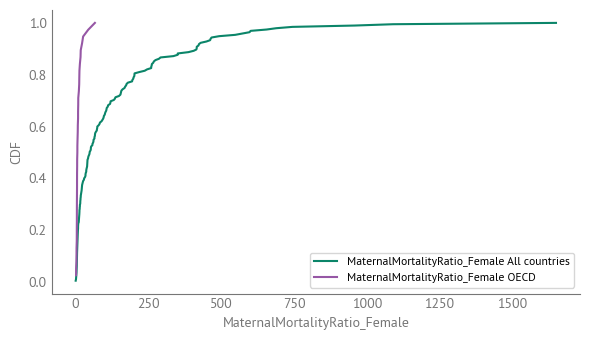

In [183]:
plot_distributions(maternal_recent)

## Homicide

**Estimates of rates of homicides per 100,000 population** - Deaths from intentional homicide, including estimates with confidence intervals.

**Indicator Code**: VIOLENCE_HOMICIDERATE  
**Relevance**: Homicide rates are typically much higher in men across most countries, making it a major contributor to the gender gap in mortality. Homicide reflects violence, conflict, and social factors that differentially affect men and women. Has excellent temporal coverage (2000-2021) and country coverage (196 countries).

In [184]:
filename = '../data/who_homicide_rates.csv'
homicide, years = load_and_inventory(filename)

(11100, 12)
['VIOLENCE_HOMICIDERATE']
['Estimates of rates of homicides per 100 000 population']
['Both sexes' 'Female' 'Male']
[nan]
[2000 2001 2002 2003 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013
 2014 2015 2016 2017 2018 2019]
['AFG' 'AGO' 'ALB' 'ARE' 'ARG' 'ARM' 'ATG' 'AUS' 'AUT' 'AZE' 'BDI' 'BEL'
 'BEN' 'BFA' 'BGD' 'BGR' 'BHR' 'BHS' 'BIH' 'BLR' 'BLZ' 'BOL' 'BRA' 'BRB'
 'BRN' 'BTN' 'BWA' 'CAF' 'CAN' 'CHE' 'CHL' 'CHN' 'CIV' 'CMR' 'COD' 'COG'
 'COL' 'COM' 'CPV' 'CRI' 'CUB' 'CYP' 'CZE' 'DEU' 'DJI' 'DNK' 'DOM' 'DZA'
 'ECU' 'EGY' 'ERI' 'ESP' 'EST' 'ETH' 'FIN' 'FJI' 'FRA' 'FSM' 'GAB' 'GBR'
 'GEO' 'GHA' 'GIN' 'GMB' 'GNB' 'GNQ' 'GRC' 'GRD' 'GTM' 'GUY' 'HND' 'HRV'
 'HTI' 'HUN' 'IDN' 'IND' 'IRL' 'IRN' 'IRQ' 'ISL' 'ISR' 'ITA' 'JAM' 'JOR'
 'JPN' 'KAZ' 'KEN' 'KGZ' 'KHM' 'KIR' 'KOR' 'KWT' 'LAO' 'LBN' 'LBR' 'LBY'
 'LCA' 'LKA' 'LSO' 'LTU' 'LUX' 'LVA' 'MAR' 'MDA' 'MDG' 'MDV' 'MEX' 'MKD'
 'MLI' 'MLT' 'MMR' 'MNE' 'MNG' 'MOZ' 'MRT' 'MUS' 'MWI' 'MYS' 'NAM' 'NER'
 'NGA' 'NIC' 'NLD' 'NOR' 'NPL' 'N

In [185]:
homicide.head()

,IndicatorCode,IndicatorName,Country,CountryCode,Year,Sex,HomicideRate,HomicideRate_Low,HomicideRate_High,Comments,DataSource,CountryName
0,VIOLENCE_HOMICIDERATE,Estimates of rates of homicides per 100 000 po...,AFG,COUNTRY,2000,Both sexes,10.433863,5.581236,16.844870,NaN,NaN,Afghanistan
1,VIOLENCE_HOMICIDERATE,Estimates of rates of homicides per 100 000 po...,AFG,COUNTRY,2001,Both sexes,10.617865,5.678589,17.162430,NaN,NaN,Afghanistan
2,VIOLENCE_HOMICIDERATE,Estimates of rates of homicides per 100 000 po...,AFG,COUNTRY,2002,Both sexes,10.953708,6.568415,16.902796,NaN,NaN,Afghanistan
3,VIOLENCE_HOMICIDERATE,Estimates of rates of homicides per 100 000 po...,AFG,COUNTRY,2003,Both sexes,10.781847,6.539156,16.757218,NaN,NaN,Afghanistan
4,VIOLENCE_HOMICIDERATE,Estimates of rates of homicides per 100 000 po...,AFG,COUNTRY,2004,Both sexes,10.135798,5.742813,16.420052,NaN,NaN,Afghanistan


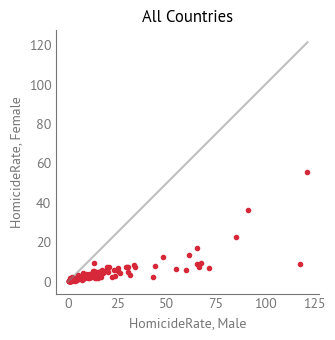

In [186]:
col = 'HomicideRate'
year = years[-1]
homicide_gap, homicide_recent = summarize_gap(homicide, col)

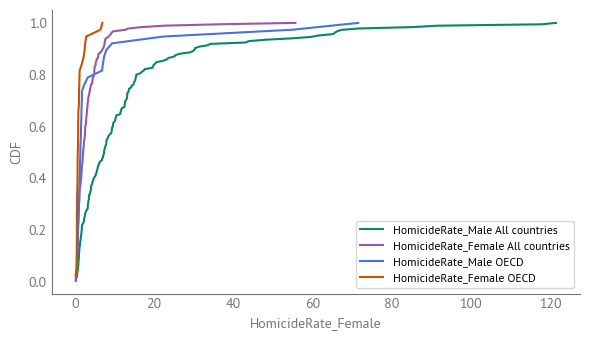

In [187]:
plot_distributions(homicide_recent)

## Intimate Partner Violence

**Proportion of ever-partnered women and girls aged 15-49 years subjected to physical and/or sexual violence by a current or former intimate partner in the previous 12 months (%)** - Prevalence indicator measuring the percentage of women experiencing intimate partner violence.

**Indicator Code**: SDGIPV  
**Relevance**: Note: This is a **prevalence indicator** (percentage), not a direct death rate. IPV affects women's health indirectly through mental health impacts, injuries, and other health consequences. It may contribute to the gender gap in HALE through its effects on women's physical and mental health, though the relationship is complex and indirect. Inherently female-specific, so only female values are used in analysis.

In [188]:
filename = '../data/who_ipv_prevalence.csv'
ipv, years = load_and_inventory(filename)

(558, 12)
['SDGIPV']
['Proportion of ever-partnered women and girls aged 15-49 years subjected to physical and/or sexual violence by a current or former intimate partner in the previous 12 months']
['Female']
['DHS '
 'calculated by FRA based on available country data from the 2012 FRA Violence against women: an EU-wide Survey  Women aged 18-74; definition of physical and sexual violence differs from the standard'
 'Violence against Women Survey 2015 '
 'Calculated by UNFPA based on available country data from the Violence against Women Survey 2015 UNECE methodology; women aged 15+'
 'PAHO 2018 publication Intimate Partner Violence against Women in the Americas: calculated by PAHO based on available country data from the Encuesta de Prevalencia y Caracteristicas de la Violencia contra las Mujeres 2016 ~ENDIREH methodology; women aged 15+; definition of sexual violence differs from the standard'
 'MICS ' 'DHS Currently married'
 'DHS Refers to currently married girls and women'
 'The Co

In [189]:
ipv.head()

,IndicatorCode,IndicatorName,Country,CountryCode,Year,Sex,IPVPrevalence,IPVPrevalence_Low,IPVPrevalence_High,Comments,DataSource,CountryName
18,SDGIPV,Proportion of ever-partnered women and girls a...,AFG,COUNTRY,2015,Female,49.1,NaN,NaN,DHS,NaN,Afghanistan
19,SDGIPV,Proportion of ever-partnered women and girls a...,AFG,COUNTRY,2015,Female,45.2,NaN,NaN,DHS,NaN,Afghanistan
20,SDGIPV,Proportion of ever-partnered women and girls a...,AFG,COUNTRY,2015,Female,51.9,NaN,NaN,DHS,NaN,Afghanistan
21,SDGIPV,Proportion of ever-partnered women and girls a...,AFG,COUNTRY,2015,Female,49.3,NaN,NaN,DHS,NaN,Afghanistan
22,SDGIPV,Proportion of ever-partnered women and girls a...,AFG,COUNTRY,2015,Female,48.6,NaN,NaN,DHS,NaN,Afghanistan


In [190]:
col = 'IPVPrevalence'
year = years[-1]
ipv_gap, ipv_recent = summarize_gap(ipv, col, sexes=['Female'])

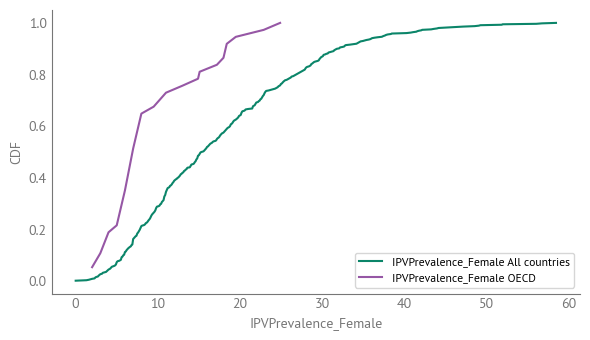

In [191]:
plot_distributions(ipv_recent)

## Under five mortality rate

**Under-five mortality rate (probability of dying by age 5 per 1000 live births)** - Deaths of children under age 5 per 1,000 live births, with gender breakdowns.

**Indicator Code**: MDG_0000000007  
**Relevance**: HALE is calculated from birth, so under-five mortality directly affects HALE calculations. If child mortality differs by gender, it directly contributes to the HALE gender gap. Infant mortality is typically higher in males (biological vulnerability + some behavioral factors). More important in lower-income countries with high child mortality. Note: MDG_0000000007 chosen over u5mr for better data quality when filtered for sex dimension.

In [192]:
filename = '../data/who_u5mr.csv'
u5mr, years = load_and_inventory(filename)

(22600, 12)
['MDG_0000000007']
['Under-five mortality rate (probability of dying by age 5 per 1000 live births)']
['Both sexes' 'Female' 'Male']
[nan
 'Some UN IGME indicators are calculated using population and live birth numbers from the World Population Prospects: The 2024 revision (WPP). The WPP numbers for Cyprus refer to the entire country. However, the underlying data used to calculate mortality rates estimates, provided by the Health Monitoring Unit of the Cyprus Ministry of Health, cover only the government-controlled areas, whereas according to Eurostat, the number of live births in 2023 was 10,295 (https://ec.europa.eu/eurostat/databrowser/view/tps00204/), the population on 1 January 2023 was 920,701 (https://ec.europa.eu/eurostat/databrowser/view/tps00001/), the population under 5 was 49,326,  adolescent population was 99,207 and the number of women of reproductive age was 235,268 (https://doi.org/10.2908/DEMO_PJAN).'
 'The UN IGME estimates are not the official statistics 

In [193]:
u5mr.head()

,IndicatorCode,IndicatorName,Country,CountryCode,Year,Sex,U5MR,U5MR_Low,U5MR_High,Comments,DataSource,CountryName
0,MDG_0000000007,Under-five mortality rate (probability of dyin...,AFG,COUNTRY,2000,Both sexes,131.657158,122.050144,142.254414,NaN,NaN,Afghanistan
1,MDG_0000000007,Under-five mortality rate (probability of dyin...,AFG,COUNTRY,2000,Both sexes,146.404320,129.690344,164.793287,NaN,NaN,Afghanistan
2,MDG_0000000007,Under-five mortality rate (probability of dyin...,AFG,COUNTRY,2000,Both sexes,116.604951,101.901270,133.012767,NaN,NaN,Afghanistan
3,MDG_0000000007,Under-five mortality rate (probability of dyin...,AFG,COUNTRY,2000,Both sexes,139.669993,126.880951,153.782482,NaN,NaN,Afghanistan
4,MDG_0000000007,Under-five mortality rate (probability of dyin...,AFG,COUNTRY,2000,Both sexes,92.831046,79.709380,107.613673,NaN,NaN,Afghanistan


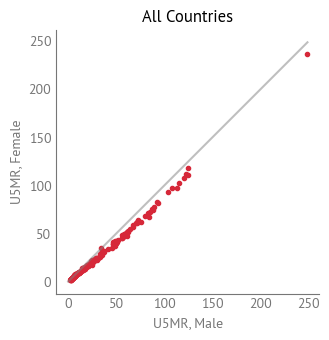

In [194]:
col = 'U5MR'
year = years[-1]
u5mr_gap, u5mr_recent = summarize_gap(u5mr, col)

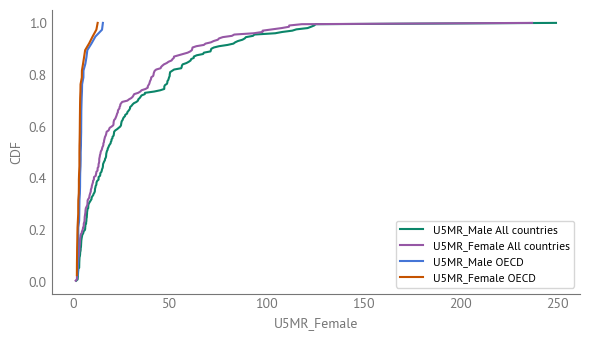

In [195]:
plot_distributions(u5mr_recent)

## Cardiovascular Disease

**Age-standardized cardiovascular disease death rates (per 100,000)** - Deaths from cardiovascular diseases (heart disease, stroke, etc.), age-standardized for cross-country comparison.

**Indicator Code**: Multiple codes tried (WHS2_161, etc.) - see `who_data.py` for implementation details  
**Relevance**: Men typically have higher rates of cardiovascular disease and heart attacks, contributing significantly to the gender gap in mortality. Risk factors include smoking, diet, and potentially biological differences. May capture effects of smoking and other risk factors. Age-standardized rates match HALE methodology.

In [196]:
filename = '../data/who_cardiovascular_death_rates.csv'
cardio, years = load_and_inventory(filename)

(573, 12)
['SA_0000001444']
[nan]
['Both sexes' 'Female' 'Male']
[nan]
[2004]
['AFG' 'AGO' 'ALB' 'AND' 'ARE' 'ARG' 'ARM' 'ATG' 'AUS' 'AUT' 'AZE' 'BDI'
 'BEL' 'BEN' 'BFA' 'BGD' 'BGR' 'BHR' 'BHS' 'BIH' 'BLR' 'BLZ' 'BOL' 'BRA'
 'BRB' 'BRN' 'BTN' 'BWA' 'CAF' 'CAN' 'CHE' 'CHL' 'CHN' 'CIV' 'CMR' 'COD'
 'COG' 'COK' 'COL' 'COM' 'CPV' 'CRI' 'CUB' 'CYP' 'CZE' 'DEU' 'DJI' 'DMA'
 'DNK' 'DOM' 'DZA' 'ECU' 'EGY' 'ERI' 'ESP' 'EST' 'ETH' 'FIN' 'FJI' 'FRA'
 'FSM' 'GAB' 'GBR' 'GEO' 'GHA' 'GIN' 'GMB' 'GNB' 'GNQ' 'GRC' 'GRD' 'GTM'
 'GUY' 'HND' 'HRV' 'HTI' 'HUN' 'IDN' 'IND' 'IRL' 'IRN' 'IRQ' 'ISL' 'ISR'
 'ITA' 'JAM' 'JOR' 'JPN' 'KAZ' 'KEN' 'KGZ' 'KHM' 'KIR' 'KNA' 'KOR' 'KWT'
 'LAO' 'LBN' 'LBR' 'LBY' 'LCA' 'LKA' 'LSO' 'LTU' 'LUX' 'LVA' 'MAR' 'MCO'
 'MDA' 'MDG' 'MDV' 'MEX' 'MHL' 'MKD' 'MLI' 'MLT' 'MMR' 'MNG' 'MOZ' 'MRT'
 'MUS' 'MWI' 'MYS' 'NAM' 'NER' 'NGA' 'NIC' 'NIU' 'NLD' 'NOR' 'NPL' 'NRU'
 'NZL' 'OMN' 'PAK' 'PAN' 'PER' 'PHL' 'PLW' 'PNG' 'POL' 'PRK' 'PRT' 'PRY'
 'QAT' 'ROU' 'RUS' 'RWA' 'SAU' 'SDN' 'SEN' 'SG

In [197]:
cardio.head()

,IndicatorCode,IndicatorName,Country,CountryCode,Year,Sex,DeathRate,DeathRate_Low,DeathRate_High,Comments,DataSource,CountryName
0,SA_0000001444,NaN,AFG,COUNTRY,2004,Both sexes,366.9,NaN,NaN,NaN,NaN,Afghanistan
1,SA_0000001444,NaN,AFG,COUNTRY,2004,Female,282.9,NaN,NaN,NaN,NaN,Afghanistan
2,SA_0000001444,NaN,AFG,COUNTRY,2004,Male,447.4,NaN,NaN,NaN,NaN,Afghanistan
3,SA_0000001444,NaN,AGO,COUNTRY,2004,Both sexes,142.4,NaN,NaN,NaN,NaN,Angola
4,SA_0000001444,NaN,AGO,COUNTRY,2004,Female,111.0,NaN,NaN,NaN,NaN,Angola


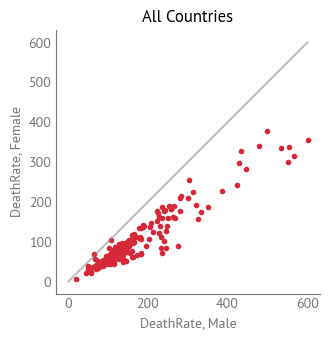

In [198]:
col = 'DeathRate'
year = years[-1]
cardio_gap, cardio_recent = summarize_gap(cardio, col)

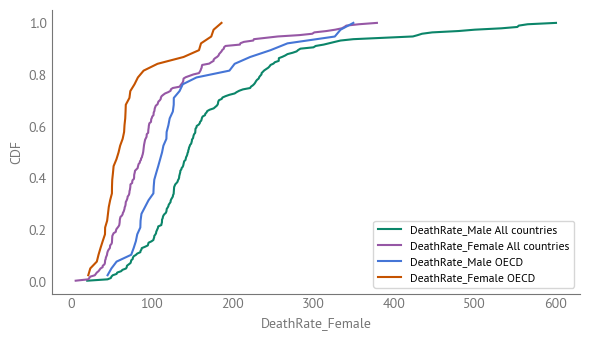

In [199]:
plot_distributions(cardio_recent)

## Diabetes

**Age-standardized death rates, diabetes mellitus (per 100,000)** - Deaths from diabetes, age-standardized for cross-country comparison.

**Indicator Code**: SA_0000001440  
**Relevance**: Diabetes is a chronic condition that can contribute to the gender gap in mortality, though the relationship may vary by country and healthcare access. Age-standardized rates match HALE methodology. **Limitation**: Only has data for 2004 (similar to cardiovascular disease indicators), which limits temporal analysis but provides a good cross-sectional snapshot.

In [200]:
filename = '../data/who_diabetes_death_rates.csv'
diabetes, years = load_and_inventory(filename)

(573, 12)
['SA_0000001440']
['Age-standardized death rates, diabetes mellitus, per 100,000']
['Both sexes' 'Female' 'Male']
[nan]
[2004]
['AFG' 'AGO' 'ALB' 'AND' 'ARE' 'ARG' 'ARM' 'ATG' 'AUS' 'AUT' 'AZE' 'BDI'
 'BEL' 'BEN' 'BFA' 'BGD' 'BGR' 'BHR' 'BHS' 'BIH' 'BLR' 'BLZ' 'BOL' 'BRA'
 'BRB' 'BRN' 'BTN' 'BWA' 'CAF' 'CAN' 'CHE' 'CHL' 'CHN' 'CIV' 'CMR' 'COD'
 'COG' 'COK' 'COL' 'COM' 'CPV' 'CRI' 'CUB' 'CYP' 'CZE' 'DEU' 'DJI' 'DMA'
 'DNK' 'DOM' 'DZA' 'ECU' 'EGY' 'ERI' 'ESP' 'EST' 'ETH' 'FIN' 'FJI' 'FRA'
 'FSM' 'GAB' 'GBR' 'GEO' 'GHA' 'GIN' 'GMB' 'GNB' 'GNQ' 'GRC' 'GRD' 'GTM'
 'GUY' 'HND' 'HRV' 'HTI' 'HUN' 'IDN' 'IND' 'IRL' 'IRN' 'IRQ' 'ISL' 'ISR'
 'ITA' 'JAM' 'JOR' 'JPN' 'KAZ' 'KEN' 'KGZ' 'KHM' 'KIR' 'KNA' 'KOR' 'KWT'
 'LAO' 'LBN' 'LBR' 'LBY' 'LCA' 'LKA' 'LSO' 'LTU' 'LUX' 'LVA' 'MAR' 'MCO'
 'MDA' 'MDG' 'MDV' 'MEX' 'MHL' 'MKD' 'MLI' 'MLT' 'MMR' 'MNG' 'MOZ' 'MRT'
 'MUS' 'MWI' 'MYS' 'NAM' 'NER' 'NGA' 'NIC' 'NIU' 'NLD' 'NOR' 'NPL' 'NRU'
 'NZL' 'OMN' 'PAK' 'PAN' 'PER' 'PHL' 'PLW' 'PNG' 'POL' 'PRK'

In [201]:
diabetes.head()

,IndicatorCode,IndicatorName,Country,CountryCode,Year,Sex,DiabetesDeathRate,DiabetesDeathRate_Low,DiabetesDeathRate_High,Comments,DataSource,CountryName
0,SA_0000001440,"Age-standardized death rates, diabetes mellitu...",AFG,COUNTRY,2004,Both sexes,29.3,NaN,NaN,NaN,NaN,Afghanistan
1,SA_0000001440,"Age-standardized death rates, diabetes mellitu...",AFG,COUNTRY,2004,Female,30.9,NaN,NaN,NaN,NaN,Afghanistan
2,SA_0000001440,"Age-standardized death rates, diabetes mellitu...",AFG,COUNTRY,2004,Male,27.5,NaN,NaN,NaN,NaN,Afghanistan
3,SA_0000001440,"Age-standardized death rates, diabetes mellitu...",AGO,COUNTRY,2004,Both sexes,67.6,NaN,NaN,NaN,NaN,Angola
4,SA_0000001440,"Age-standardized death rates, diabetes mellitu...",AGO,COUNTRY,2004,Female,74.2,NaN,NaN,NaN,NaN,Angola


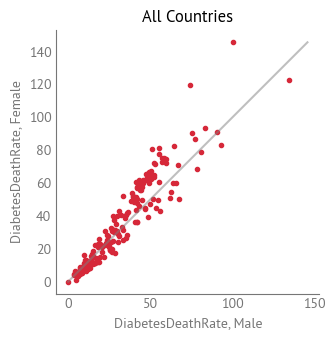

In [202]:
col = 'DiabetesDeathRate'
year = years[-1]
diabetes_gap, diabetes_recent = summarize_gap(diabetes, col)

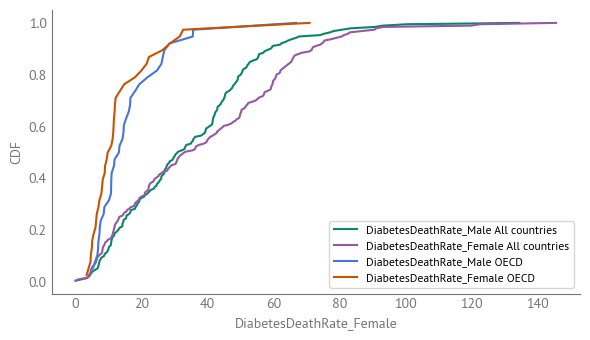

In [203]:
plot_distributions(diabetes_recent)

## NCD Mortality (30-70 years)

**Probability (%) of dying between age 30 and exact age 70 from any of cardiovascular disease, cancer, diabetes, or chronic respiratory disease** - Combined non-communicable disease mortality indicator.

**Indicator Code**: NCDMORT3070  
**Relevance**: Combines multiple causes of death (cardiovascular disease, cancer, diabetes, chronic respiratory disease), so it's less specific than individual cause indicators. However, it has much better temporal coverage (2000-2021) than diabetes-specific indicators (which only have 2004 data). This makes it useful for model comparison - trading off specificity for temporal coverage. The combined indicator may capture overall NCD mortality patterns that contribute to the HALE gender gap.

In [204]:
filename = '../data/who_ncd_mortality_30_70.csv'
ncdmort, years = load_and_inventory(filename)

(11100, 12)
['NCDMORT3070']
['Probability (%) of dying between age 30 and exact age 70 from any of cardiovascular disease, cancer, diabetes, or chronic respiratory disease']
['Both sexes' 'Female' 'Male']
[nan]
[2000 2001 2002 2003 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013
 2014 2015 2016 2017 2018 2019]
['AFG' 'AGO' 'ALB' 'ARE' 'ARG' 'ARM' 'ATG' 'AUS' 'AUT' 'AZE' 'BDI' 'BEL'
 'BEN' 'BFA' 'BGD' 'BGR' 'BHR' 'BHS' 'BIH' 'BLR' 'BLZ' 'BOL' 'BRA' 'BRB'
 'BRN' 'BTN' 'BWA' 'CAF' 'CAN' 'CHE' 'CHL' 'CHN' 'CIV' 'CMR' 'COD' 'COG'
 'COL' 'COM' 'CPV' 'CRI' 'CUB' 'CYP' 'CZE' 'DEU' 'DJI' 'DNK' 'DOM' 'DZA'
 'ECU' 'EGY' 'ERI' 'ESP' 'EST' 'ETH' 'FIN' 'FJI' 'FRA' 'FSM' 'GAB' 'GBR'
 'GEO' 'GHA' 'GIN' 'GMB' 'GNB' 'GNQ' 'GRC' 'GRD' 'GTM' 'GUY' 'HND' 'HRV'
 'HTI' 'HUN' 'IDN' 'IND' 'IRL' 'IRN' 'IRQ' 'ISL' 'ISR' 'ITA' 'JAM' 'JOR'
 'JPN' 'KAZ' 'KEN' 'KGZ' 'KHM' 'KIR' 'KOR' 'KWT' 'LAO' 'LBN' 'LBR' 'LBY'
 'LCA' 'LKA' 'LSO' 'LTU' 'LUX' 'LVA' 'MAR' 'MDA' 'MDG' 'MDV' 'MEX' 'MKD'
 'MLI' 'MLT' 'MMR' 'MNE' 'MNG

In [205]:
ncdmort.head()

,IndicatorCode,IndicatorName,Country,CountryCode,Year,Sex,NCDMortality30_70,NCDMortality30_70_Low,NCDMortality30_70_High,Comments,DataSource,CountryName
0,NCDMORT3070,Probability (%) of dying between age 30 and ex...,AFG,COUNTRY,2000,Both sexes,43.2,25.6,60.0,NaN,NaN,Afghanistan
1,NCDMORT3070,Probability (%) of dying between age 30 and ex...,AFG,COUNTRY,2001,Both sexes,43.5,25.8,60.3,NaN,NaN,Afghanistan
2,NCDMORT3070,Probability (%) of dying between age 30 and ex...,AFG,COUNTRY,2002,Both sexes,43.1,25.7,60.2,NaN,NaN,Afghanistan
3,NCDMORT3070,Probability (%) of dying between age 30 and ex...,AFG,COUNTRY,2003,Both sexes,42.5,25.6,60.1,NaN,NaN,Afghanistan
4,NCDMORT3070,Probability (%) of dying between age 30 and ex...,AFG,COUNTRY,2004,Both sexes,42.3,25.6,60.0,NaN,NaN,Afghanistan


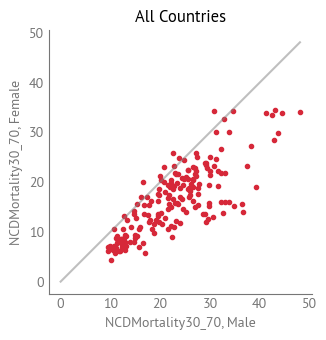

In [206]:
col = 'NCDMortality30_70'
year = years[-1]
ncdmort_gap, ncdmort_recent = summarize_gap(ncdmort, col)

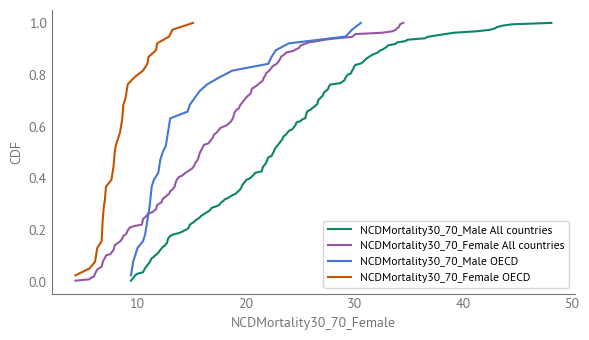

In [207]:
plot_distributions(ncdmort_recent)

## Phase 1: Data Preparation for Regression Analysis

### Step 1.2: Prepare Target Variable (HALE Gender Gap)

In [208]:
# Calculate HALE gender gap from existing hale_recent DataFrame
hale_recent['HALE_gap'] = hale_recent['HALE_Years_Female'] - hale_recent['HALE_Years_Male']

# Filter to OECD countries
hale_oecd = get_oecd(hale_recent)

# Display summary
hale_oecd[['HALE_Years_Male', 'HALE_Years_Female', 'HALE_gap']].describe()

,HALE_Years_Male,HALE_Years_Female,HALE_gap
count,38.000000,38.000000,38.000000
mean,68.627594,70.605057,1.977462
std,2.533251,1.620032,1.601449
min,63.046587,66.927903,0.018589
25%,66.703502,69.990711,0.870341
50%,69.438269,70.730471,1.385737
75%,70.795272,71.462018,2.923884
max,72.085115,75.013962,6.062020


In [209]:
# Diagnostic: Check Israel's (ISR) HALE values
if 'ISR' in hale_recent.index:
    isr_data = hale_recent.loc[['ISR']]
    print("=== Israel (ISR) HALE Data ===")
    print(isr_data[['HALE_Years_Male', 'HALE_Years_Female', 'HALE_gap']])
    if 'CountryName' in isr_data.columns:
        print(f"Country Name: {isr_data['CountryName'].iloc[0]}")
    
    # Check if this is an outlier
    print(f"\nHALE Gap: {isr_data['HALE_gap'].iloc[0]:.2f} years")
    print(f"Male HALE: {isr_data['HALE_Years_Male'].iloc[0]:.2f} years")
    print(f"Female HALE: {isr_data['HALE_Years_Female'].iloc[0]:.2f} years")
    
    # Compare to other countries
    print(f"\nCountries with negative HALE gap (men > women):")
    negative_gap = hale_recent[hale_recent['HALE_gap'] < 0]
    if len(negative_gap) > 0:
        print(negative_gap[['HALE_Years_Male', 'HALE_Years_Female', 'HALE_gap']].sort_values('HALE_gap'))
    else:
        print("No other countries with negative gap found")
    
    # Check raw HALE data for Israel to see if there's a data issue
    print(f"\n=== Checking raw HALE data for Israel ===")
    if 'ISR' in hale.index:
        isr_raw = hale[hale['Country'] == 'ISR'].sort_values('Year')
        print(f"Years available: {sorted(isr_raw['Year'].unique())}")
        print(f"\nRaw data by year and sex:")
        print(isr_raw[['Year', 'Sex', 'HALE_Years']].pivot(index='Year', columns='Sex', values='HALE_Years'))
else:
    print("Israel (ISR) not found in hale_recent")

=== Israel (ISR) HALE Data ===
         HALE_Years_Male  HALE_Years_Female  HALE_gap
Country                                              
ISR            71.174433          71.784999  0.610566
Country Name: Israel

HALE Gap: 0.61 years
Male HALE: 71.17 years
Female HALE: 71.78 years

Countries with negative HALE gap (men > women):
         HALE_Years_Male  HALE_Years_Female  HALE_gap
Country                                              
JOR            69.585018          67.324152 -2.260866
QAT            68.367710          66.544907 -1.822802
DZA            67.040830          65.337051 -1.703780
MRT            62.488875          60.821382 -1.667493
BHR            66.301313          64.717522 -1.583791
ARE            70.244253          68.685607 -1.558646
COG            55.296261          54.056384 -1.239877
HTI            55.562416          54.467865 -1.094551
MAR            64.131324          63.043466 -1.087858
LBR            54.536795          53.474988 -1.061807
MLI            54.2

### Step 1.4: Merge All Predictors into Single Dataset

In [210]:
# Start with HALE data as base
analysis_df = hale_oecd[['HALE_Years_Male', 'HALE_Years_Female', 'HALE_gap']].copy()

# Merge all predictor DataFrames (already filtered to OECD in earlier sections)
# Note: We will exclude gap columns (_Gap), CountryName, and Year columns before merging
# Gap columns are perfectly collinear with male/female columns
predictor_dfs = {
    'SmokingPrevalence': get_oecd(smoking_recent),
    'CardioDeathRate': get_oecd(cardio_recent),  # Cardiovascular
    'SuicideRate': get_oecd(suicide_recent),
    'AlcoholDeathRate': get_oecd(alcohol_recent),
    'PoisoningRate': get_oecd(poison_recent),
    'RoadTrafficDeathRate': get_oecd(traffic_recent),
    'HomicideRate': get_oecd(homicide_recent),
    'MaternalMortalityRatio': get_oecd(maternal_recent),
    'U5MR': get_oecd(u5mr_recent),
    'DiabetesDeathRate': get_oecd(diabetes_recent),
    'NCDMortality30_70': get_oecd(ncdmort_recent),
}

In [211]:
for name, df in predictor_dfs.items():
    year_counts = df['Year'].value_counts()
    print(name, year_counts)

SmokingPrevalence Year
2015    38
Name: count, dtype: int64
CardioDeathRate Year
2004    38
Name: count, dtype: int64
SuicideRate Year
2019    38
Name: count, dtype: int64
AlcoholDeathRate Year
2019    38
Name: count, dtype: int64
PoisoningRate Year
2019    38
Name: count, dtype: int64
RoadTrafficDeathRate Year
2019    38
Name: count, dtype: int64
HomicideRate Year
2019    38
Name: count, dtype: int64
MaternalMortalityRatio Year
2019    38
Name: count, dtype: int64
U5MR Year
2019    38
Name: count, dtype: int64
DiabetesDeathRate Year
2004    38
Name: count, dtype: int64
NCDMortality30_70 Year
2019    38
Name: count, dtype: int64


In [212]:

for name, df in predictor_dfs.items():
    drop_cols = ['CountryName', 'Year']
    drop_cols += [col for col in df.columns if col.endswith('_Gap')]
    if drop_cols:
        predictor_dfs[name] = df.drop(columns=drop_cols)

# Check shapes after removing gaps
for name, predictor_df in predictor_dfs.items():
    print(name, predictor_df.shape)

SmokingPrevalence (38, 2)
CardioDeathRate (38, 2)
SuicideRate (38, 2)
AlcoholDeathRate (38, 2)
PoisoningRate (38, 2)
RoadTrafficDeathRate (38, 2)
HomicideRate (38, 2)
MaternalMortalityRatio (38, 1)
U5MR (38, 2)
DiabetesDeathRate (38, 2)
NCDMortality30_70 (38, 2)


In [213]:
# Merge all predictors on index (Country codes)
for name, df in predictor_dfs.items():
    analysis_df = analysis_df.join(df, how='outer')

# Display shape and column names
analysis_df.shape

(38, 24)

In [214]:
analysis_df.head()

,HALE_Years_Male,HALE_Years_Female,HALE_gap,SmokingPrevalence_Male,SmokingPrevalence_Female,DeathRate_Male,DeathRate_Female,SuicideRate_Male,SuicideRate_Female,AlcoholDeathRate_Male,...,RoadTrafficDeathRate_Female,HomicideRate_Male,HomicideRate_Female,MaternalMortalityRatio_Female,U5MR_Male,U5MR_Female,DiabetesDeathRate_Male,DiabetesDeathRate_Female,NCDMortality30_70_Male,NCDMortality30_70_Female
Country,,,,,,,,,,,,,,,,,,,,,
AUS,69.678894,70.839417,1.160523,18.1,13.7,95.9,52.6,19.262646,6.316721,30.074132,...,2.270707,1.266373,0.657008,5.293546,4.105110,3.446807,13.1,8.0,11.0,6.9
AUT,69.734435,71.097603,1.363167,33.3,29.8,112.6,67.0,16.571323,4.693402,48.422765,...,1.896172,0.554054,0.499875,6.606055,3.796687,3.173931,26.9,17.9,12.9,7.9
BEL,69.611904,70.552460,0.940556,29.8,22.2,105.4,50.6,20.837616,7.684374,40.641776,...,2.406752,1.466520,1.134963,4.320729,4.353265,3.482878,7.2,8.2,12.0,8.0
CAN,69.657904,70.912614,1.254710,18.2,13.5,102.3,50.9,16.488952,5.638187,35.024350,...,2.889542,2.390765,0.845760,12.266445,5.540480,4.733152,18.0,12.1,11.4,7.8
CHE,71.330820,71.668585,0.337766,29.6,23.2,85.7,46.6,13.921306,5.835274,28.127289,...,0.822037,0.546259,0.442086,5.932969,4.364372,3.691953,11.6,8.8,9.6,6.2


In [215]:
# Create missing data report
missing_report = pd.DataFrame({
    'Indicator': analysis_df.columns,
    'Missing_Count': [analysis_df[col].isna().sum() for col in analysis_df.columns],
    'Missing_Pct': [analysis_df[col].isna().sum() / len(analysis_df) * 100 for col in analysis_df.columns],
    'Available_Count': [analysis_df[col].notna().sum() for col in analysis_df.columns]
}).sort_values('Missing_Count', ascending=False)

missing_report

,Indicator,Missing_Count,Missing_Pct,Available_Count
0,HALE_Years_Male,0,0.0,38
1,HALE_Years_Female,0,0.0,38
22,NCDMortality30_70_Male,0,0.0,38
21,DiabetesDeathRate_Female,0,0.0,38
20,DiabetesDeathRate_Male,0,0.0,38
19,U5MR_Female,0,0.0,38
18,U5MR_Male,0,0.0,38
17,MaternalMortalityRatio_Female,0,0.0,38
16,HomicideRate_Female,0,0.0,38
15,HomicideRate_Male,0,0.0,38


In [216]:
# Show which countries have complete data for all indicators
complete_cases = analysis_df.dropna()
complete_cases.shape[0], f"{complete_cases.shape[0] / len(analysis_df) * 100:.1f}% of countries have complete data"

(38, '100.0% of countries have complete data')

In [217]:
#bad = analysis_df['IPVPrevalence_Female'].isna()
#analysis_df.loc[bad].index.map(code_to_who_country)

### Step 1.5: Create Final Analysis Dataset

In [218]:
# Use complete-case analysis for primary model
analysis_complete = analysis_df.dropna()

# Document excluded countries
excluded_countries = set(analysis_df.index) - set(analysis_complete.index)
excluded_countries if excluded_countries else "No countries excluded - all OECD countries have complete data"

'No countries excluded - all OECD countries have complete data'

In [219]:
# Separate target and predictors
target = analysis_complete['HALE_gap']
predictors = analysis_complete.drop(columns=['HALE_gap', 'HALE_Years_Male', 'HALE_Years_Female'])

# Display final dataset info
pd.DataFrame({
    'Dataset': ['Complete Cases'],
    'Countries': [len(analysis_complete)],
    'Target_Variable': ['HALE_gap'],
    'Number_of_Predictors': [len(predictors.columns)],
    'Predictor_Names': [', '.join(predictors.columns)]
})

,Dataset,Countries,Target_Variable,Number_of_Predictors,Predictor_Names
0,Complete Cases,38,HALE_gap,21,"SmokingPrevalence_Male, SmokingPrevalence_Fema..."


In [220]:
# Summary of Phase 1 completion
pd.DataFrame({
    'Step': ['1.2: Target Variable', '1.4: Merge', '1.5: Complete Cases'],
    'Status': ['Complete', 'Complete', 'Complete'],
    'Countries': [len(hale_oecd), len(analysis_df), len(analysis_complete)],
    'Variables': [3, len(analysis_df.columns), len(analysis_complete.columns)]
})

,Step,Status,Countries,Variables
0,1.2: Target Variable,Complete,38,3
1,1.4: Merge,Complete,38,24
2,1.5: Complete Cases,Complete,38,24


**Note**: Predictor standardization will be done as part of the regression pipeline (e.g., using `StandardScaler` in scikit-learn's pipeline), not as a separate preprocessing step.

## Phase 2: Exploratory Data Analysis

### Step 2.1: Descriptive Statistics

In [221]:
target.sort_values()

Country
NLD    0.018589
SWE    0.134025
ISL    0.160198
NOR    0.238734
CHE    0.337766
IRL    0.454396
NZL    0.486508
ISR    0.610566
GBR    0.694553
DEU    0.862288
DNK    0.894501
LUX    0.914529
BEL    0.940556
ITA    1.071289
AUS    1.160523
TUR    1.169973
CAN    1.254710
GRC    1.325006
AUT    1.363167
CHL    1.408306
ESP    1.523123
USA    1.800777
FRA    1.817945
FIN    2.243172
CRI    2.258242
PRT    2.391484
COL    2.892291
SVN    2.908994
JPN    2.928847
CZE    3.091037
MEX    3.095419
KOR    3.564595
HUN    3.722175
SVK    3.930964
EST    4.790534
POL    4.929800
LVA    5.691968
LTU    6.062020
Name: HALE_gap, dtype: float64

In [222]:
# Summary statistics for target variable (HALE gap)
target.describe()

count    38.000000
mean      1.977462
std       1.601449
min       0.018589
25%       0.870341
50%       1.385737
75%       2.923884
max       6.062020
Name: HALE_gap, dtype: float64

In [223]:
# Summary statistics for all predictors
predictors.describe()

,SmokingPrevalence_Male,SmokingPrevalence_Female,DeathRate_Male,DeathRate_Female,SuicideRate_Male,SuicideRate_Female,AlcoholDeathRate_Male,AlcoholDeathRate_Female,PoisoningRate_Male,PoisoningRate_Female,...,RoadTrafficDeathRate_Female,HomicideRate_Male,HomicideRate_Female,MaternalMortalityRatio_Female,U5MR_Male,U5MR_Female,DiabetesDeathRate_Male,DiabetesDeathRate_Female,NCDMortality30_70_Male,NCDMortality30_70_Female
count,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,...,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000
mean,29.144737,19.857895,136.960526,73.242105,15.683649,4.778025,51.670267,13.524238,0.516938,0.199204,...,2.502601,5.908545,1.220929,10.386346,5.040331,4.226633,16.213158,13.644737,14.963158,8.592105
std,8.869434,7.092426,77.286632,44.584221,6.373638,2.315249,39.794802,17.253014,0.520076,0.137967,...,1.512827,14.404683,1.449328,12.246133,3.111852,2.591025,11.713314,12.283821,5.873873,2.278380
min,14.100000,5.400000,45.100000,21.200000,5.462428,1.428371,12.860832,2.859710,0.001308,0.000505,...,0.586627,0.240748,0.183065,1.587783,2.537916,2.133197,5.200000,3.300000,9.500000,4.400000
25%,21.975000,16.375000,88.200000,45.850000,11.922116,3.150607,29.301366,6.499013,0.250998,0.106487,...,1.393871,0.945993,0.500611,4.289471,3.385258,2.828963,8.550000,6.525000,11.125000,7.000000
50%,28.750000,19.850000,113.450000,59.700000,15.574885,4.795838,40.036996,8.540945,0.375002,0.181245,...,2.187712,1.371191,0.737735,5.971343,4.172973,3.466179,13.200000,10.250000,12.550000,8.050000
75%,36.125000,23.200000,137.300000,77.200000,19.233786,5.906438,51.733670,11.797030,0.560288,0.256098,...,3.095540,2.233082,1.085750,11.973693,4.821946,4.011590,18.975000,14.700000,16.325000,9.175000
max,46.300000,34.000000,349.700000,186.300000,37.016864,13.210332,187.011110,80.287815,2.836687,0.640002,...,6.631922,71.573911,6.926356,66.191870,15.548194,12.848685,66.800000,70.900000,30.600000,15.200000


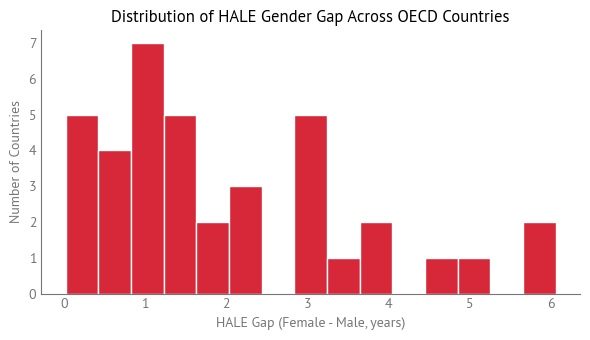

In [224]:
# Distribution of HALE gap across OECD countries
plt.hist(target, bins=15, color=AIBM_COLORS['crimson'], edgecolor='white')
decorate(xlabel='HALE Gap (Female - Male, years)', 
         ylabel='Number of Countries',
         title='Distribution of HALE Gender Gap Across OECD Countries')

In [225]:
# Identify potential outliers using IQR method
Q1 = target.quantile(0.25)
Q3 = target.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = target[(target < lower_bound) | (target > upper_bound)]
outliers_df = pd.DataFrame({
    'Country': outliers.index,
    'HALE_Gap': outliers.values
}).sort_values('HALE_Gap')

outliers_df if not outliers_df.empty else "No outliers detected using IQR method"

,Country,HALE_Gap
0,LTU,6.06202


### Step 2.2: Correlation Analysis

In [226]:
# Calculate correlation matrix of all predictors
correlation_matrix = predictors.corr()

# Display correlation matrix
correlation_matrix

,SmokingPrevalence_Male,SmokingPrevalence_Female,DeathRate_Male,DeathRate_Female,SuicideRate_Male,SuicideRate_Female,AlcoholDeathRate_Male,AlcoholDeathRate_Female,PoisoningRate_Male,PoisoningRate_Female,...,RoadTrafficDeathRate_Female,HomicideRate_Male,HomicideRate_Female,MaternalMortalityRatio_Female,U5MR_Male,U5MR_Female,DiabetesDeathRate_Male,DiabetesDeathRate_Female,NCDMortality30_70_Male,NCDMortality30_70_Female
SmokingPrevalence_Male,1.000000,0.515581,0.424616,0.452418,0.222177,-0.042234,0.485468,0.450653,0.356416,0.341093,...,0.059276,-0.253147,-0.135722,-0.189976,-0.099910,-0.092116,-0.082041,-0.082655,0.633761,0.291434
SmokingPrevalence_Female,0.515581,1.000000,0.180719,0.102045,-0.071412,-0.224525,0.173067,0.117762,0.097793,0.180502,...,-0.156200,-0.501699,-0.480875,-0.472062,-0.389718,-0.393797,-0.416106,-0.463903,0.296831,0.143717
DeathRate_Male,0.424616,0.180719,1.000000,0.961000,0.401553,-0.161265,0.836211,0.802104,0.718808,0.510057,...,0.154725,0.025215,0.202344,0.073330,0.046090,0.044781,-0.238071,-0.163778,0.875621,0.710535
DeathRate_Female,0.452418,0.102045,0.961000,1.000000,0.284185,-0.227695,0.730784,0.699576,0.631645,0.463740,...,0.240179,0.120984,0.290163,0.179641,0.225822,0.229992,-0.120381,-0.019800,0.868118,0.750756
SuicideRate_Male,0.222177,-0.071412,0.401553,0.284185,1.000000,0.700049,0.669639,0.656356,0.612751,0.460491,...,0.045521,-0.231418,-0.063669,-0.218241,-0.354817,-0.361511,-0.169670,-0.261076,0.363006,0.125325
SuicideRate_Female,-0.042234,-0.224525,-0.161265,-0.227695,0.700049,1.000000,0.067644,0.114657,0.001777,-0.011961,...,-0.195413,-0.311517,-0.254429,-0.304536,-0.446621,-0.453961,-0.132795,-0.266529,-0.219263,-0.352556
AlcoholDeathRate_Male,0.485468,0.173067,0.836211,0.730784,0.669639,0.067644,1.000000,0.946049,0.770091,0.552167,...,0.158411,0.012407,0.216826,0.062323,-0.086485,-0.095010,-0.121425,-0.110030,0.823768,0.590319
AlcoholDeathRate_Female,0.450653,0.117762,0.802104,0.699576,0.656356,0.114657,0.946049,1.000000,0.740877,0.489470,...,0.078980,-0.035230,0.184035,0.032096,-0.139978,-0.142291,-0.225770,-0.206783,0.720088,0.464642
PoisoningRate_Male,0.356416,0.097793,0.718808,0.631645,0.612751,0.001777,0.770091,0.740877,1.000000,0.802916,...,0.182065,-0.005332,0.157160,-0.043889,-0.028139,-0.030212,-0.169384,-0.127446,0.695890,0.512065
PoisoningRate_Female,0.341093,0.180502,0.510057,0.463740,0.460491,-0.011961,0.552167,0.489470,0.802916,1.000000,...,0.295630,-0.011926,0.155014,-0.009561,0.055800,0.050930,-0.164097,-0.091209,0.648032,0.568223


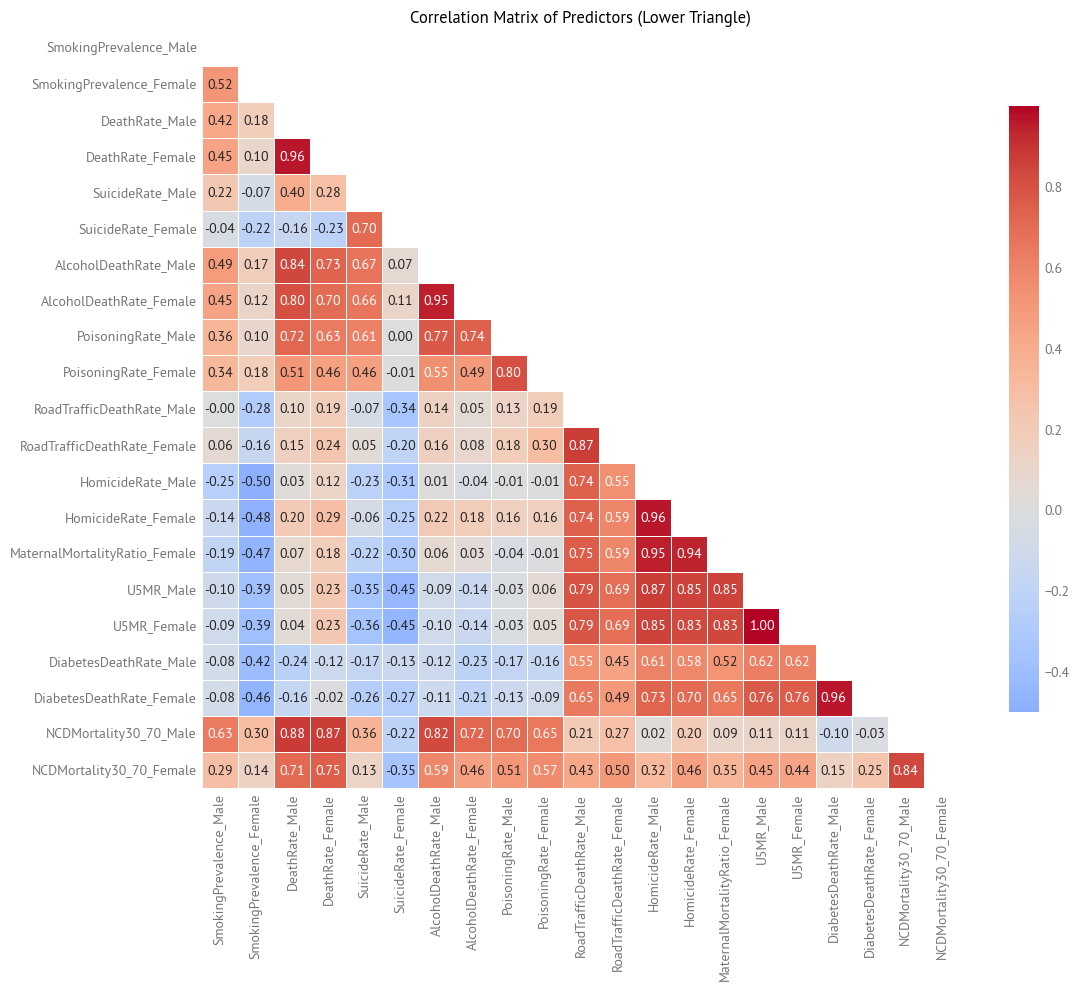

In [227]:
# Visualize correlation matrix as heatmap
import seaborn as sns

plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))  # Mask upper triangle
sns.heatmap(correlation_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
decorate(title='Correlation Matrix of Predictors (Lower Triangle)')
plt.tight_layout()

In [228]:
# Identify highly correlated predictor pairs (|correlation| > 0.7)
high_corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr_val = correlation_matrix.iloc[i, j]
        if abs(corr_val) > 0.7:
            high_corr_pairs.append({
                'Predictor_1': correlation_matrix.columns[i],
                'Predictor_2': correlation_matrix.columns[j],
                'Correlation': corr_val
            })

high_corr_df = pd.DataFrame(high_corr_pairs).sort_values('Correlation', key=abs, ascending=False)
high_corr_df if not high_corr_df.empty else "No highly correlated pairs (|r| > 0.7) found"

,Predictor_1,Predictor_2,Correlation
33,U5MR_Male,U5MR_Female,0.998492
0,DeathRate_Male,DeathRate_Female,0.961000
36,DiabetesDeathRate_Male,DiabetesDeathRate_Female,0.959485
22,HomicideRate_Male,HomicideRate_Female,0.959071
23,HomicideRate_Male,MaternalMortalityRatio_Female,0.950210
10,AlcoholDeathRate_Male,AlcoholDeathRate_Female,0.946049
27,HomicideRate_Female,MaternalMortalityRatio_Female,0.937440
4,DeathRate_Male,NCDMortality30_70_Male,0.875621
24,HomicideRate_Male,U5MR_Male,0.869030
7,DeathRate_Female,NCDMortality30_70_Male,0.868118


In [229]:
# Summary of correlation analysis
pd.DataFrame({
    'Analysis': ['Total Predictors', 'High Correlations (|r| > 0.7)', 'Max Correlation', 'Min Correlation'],
    'Value': [
        len(predictors.columns),
        len(high_corr_pairs) if high_corr_pairs else 0,
        correlation_matrix.values[np.triu_indices_from(correlation_matrix.values, k=1)].max(),
        correlation_matrix.values[np.triu_indices_from(correlation_matrix.values, k=1)].min()
    ]
})

,Analysis,Value
0,Total Predictors,21.000000
1,High Correlations (|r| > 0.7),38.000000
2,Max Correlation,0.998492
3,Min Correlation,-0.501699


## Phase 3: Model Fitting

### Step 3.1: Model Selection Setup

In [230]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.model_selection import GridSearchCV, cross_val_score, KFold
from sklearn.metrics import r2_score, mean_squared_error

# Prepare data: X (predictors) and y (target)
X = predictors.copy()
y = target.copy()

# Display data shape
pd.DataFrame({
    'Data': ['Predictors (X)', 'Target (y)'],
    'Shape': [X.shape, y.shape],
    'Countries': [X.shape[0], y.shape[0]]
})

,Data,Shape,Countries
0,Predictors (X),"(38, 21)",38
1,Target (y),"(38,)",38


In [231]:
# Set up cross-validation (5-fold for small sample size)
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Display CV setup
f"Using {cv.n_splits}-fold cross-validation for model selection"

'Using 5-fold cross-validation for model selection'

### Step 3.2: Fit Multiple Models

In [232]:
# Define parameter grids for each model
ridge_params = {'ridge__alpha': np.logspace(-2, 4, 50)}  # Regularization strength
lasso_params = {'lasso__alpha': np.logspace(-3, 1, 50)}
elastic_net_params = {
    'elasticnet__alpha': np.logspace(-3, 1, 20),
    'elasticnet__l1_ratio': np.linspace(0.1, 0.9, 9)  # 0=Ridge, 1=Lasso
}

# Create pipelines with StandardScaler and models
ridge_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge())
])

lasso_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', Lasso(max_iter=10000))
])

elastic_net_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('elasticnet', ElasticNet(max_iter=10000))
])

In [233]:
# Fit Ridge Regression with cross-validation
print("Fitting Ridge Regression...")
ridge_grid = GridSearchCV(ridge_pipeline, ridge_params, cv=cv, 
                          scoring='r2', n_jobs=-1, verbose=1)
ridge_grid.fit(X, y)

ridge_best_score = ridge_grid.best_score_
ridge_best_params = ridge_grid.best_params_
ridge_best_model = ridge_grid.best_estimator_

pd.DataFrame({
    'Model': ['Ridge'],
    'Best_CV_R2': [ridge_best_score],
    'Best_Alpha': [ridge_best_params['ridge__alpha']]
})

Fitting Ridge Regression...
Fitting 5 folds for each of 50 candidates, totalling 250 fits


,Model,Best_CV_R2,Best_Alpha
0,Ridge,0.731871,0.390694


In [234]:
# Fit Lasso Regression with cross-validation
print("Fitting Lasso Regression...")
lasso_grid = GridSearchCV(lasso_pipeline, lasso_params, cv=cv,
                          scoring='r2', n_jobs=-1, verbose=1)
lasso_grid.fit(X, y)

lasso_best_score = lasso_grid.best_score_
lasso_best_params = lasso_grid.best_params_
lasso_best_model = lasso_grid.best_estimator_

pd.DataFrame({
    'Model': ['Lasso'],
    'Best_CV_R2': [lasso_best_score],
    'Best_Alpha': [lasso_best_params['lasso__alpha']]
})

Fitting Lasso Regression...
Fitting 5 folds for each of 50 candidates, totalling 250 fits


,Model,Best_CV_R2,Best_Alpha
0,Lasso,0.734214,0.013895


In [235]:
# Fit Elastic Net with cross-validation
print("Fitting Elastic Net...")
elastic_net_grid = GridSearchCV(elastic_net_pipeline, elastic_net_params, cv=cv,
                                 scoring='r2', n_jobs=-1, verbose=1)
elastic_net_grid.fit(X, y)

elastic_net_best_score = elastic_net_grid.best_score_
elastic_net_best_params = elastic_net_grid.best_params_
elastic_net_best_model = elastic_net_grid.best_estimator_

pd.DataFrame({
    'Model': ['Elastic Net'],
    'Best_CV_R2': [elastic_net_best_score],
    'Best_Alpha': [elastic_net_best_params['elasticnet__alpha']],
    'Best_L1_Ratio': [elastic_net_best_params['elasticnet__l1_ratio']]
})

Fitting Elastic Net...
Fitting 5 folds for each of 180 candidates, totalling 900 fits


,Model,Best_CV_R2,Best_Alpha,Best_L1_Ratio
0,Elastic Net,0.733649,0.011288,0.4


### Step 3.3: Model Comparison

In [236]:
# Calculate RMSE from cross-validation for each model
ridge_rmse_scores = np.sqrt(-cross_val_score(ridge_best_model, X, y, cv=cv, scoring='neg_mean_squared_error'))
lasso_rmse_scores = np.sqrt(-cross_val_score(lasso_best_model, X, y, cv=cv, scoring='neg_mean_squared_error'))
elastic_net_rmse_scores = np.sqrt(-cross_val_score(elastic_net_best_model, X, y, cv=cv, scoring='neg_mean_squared_error'))

# Compare cross-validation scores
model_comparison = pd.DataFrame({
    'Model': ['Ridge', 'Lasso', 'Elastic Net'],
    'CV_R2_Score': [ridge_best_score, lasso_best_score, elastic_net_best_score],
    'CV_RMSE_Mean': [
        ridge_rmse_scores.mean(),
        lasso_rmse_scores.mean(),
        elastic_net_rmse_scores.mean()
    ],
    'CV_RMSE_Std': [
        ridge_rmse_scores.std(),
        lasso_rmse_scores.std(),
        elastic_net_rmse_scores.std()
    ]
})

model_comparison.sort_values('CV_R2_Score', ascending=False)

,Model,CV_R2_Score,CV_RMSE_Mean,CV_RMSE_Std
1,Lasso,0.734214,0.556278,0.146739
2,Elastic Net,0.733649,0.533364,0.117291
0,Ridge,0.731871,0.538875,0.117313


In [237]:
# Extract coefficients from each model (on standardized scale)
ridge_coefs = pd.DataFrame({
    'Predictor': X.columns,
    'Ridge_Coefficient': ridge_best_model.named_steps['ridge'].coef_
}).sort_values('Ridge_Coefficient', key=abs, ascending=False)

lasso_coefs = pd.DataFrame({
    'Predictor': X.columns,
    'Lasso_Coefficient': lasso_best_model.named_steps['lasso'].coef_
}).sort_values('Lasso_Coefficient', key=abs, ascending=False)

elastic_net_coefs = pd.DataFrame({
    'Predictor': X.columns,
    'ElasticNet_Coefficient': elastic_net_best_model.named_steps['elasticnet'].coef_
}).sort_values('ElasticNet_Coefficient', key=abs, ascending=False)

# Merge coefficient comparisons
coef_comparison = ridge_coefs.merge(lasso_coefs, on='Predictor').merge(elastic_net_coefs, on='Predictor')
coef_comparison

,Predictor,Ridge_Coefficient,Lasso_Coefficient,ElasticNet_Coefficient
0,AlcoholDeathRate_Male,1.290311,1.658984,1.403354
1,AlcoholDeathRate_Female,-0.942779,-1.112147,-0.959032
2,HomicideRate_Male,0.902158,0.410107,0.833770
3,NCDMortality30_70_Male,0.766045,0.652256,0.763617
4,SuicideRate_Male,0.675230,0.386509,0.554768
5,HomicideRate_Female,-0.538762,-0.027596,-0.423839
6,SmokingPrevalence_Male,0.532921,0.433017,0.482743
7,SmokingPrevalence_Female,-0.512969,-0.436728,-0.484389
8,SuicideRate_Female,-0.408168,-0.235921,-0.334002
9,DeathRate_Female,-0.401518,-0.003335,-0.181640


In [238]:
# Count non-zero coefficients (feature selection in Lasso/Elastic Net)
feature_selection_summary = pd.DataFrame({
    'Model': ['Ridge', 'Lasso', 'Elastic Net'],
    'Total_Predictors': [len(X.columns), len(X.columns), len(X.columns)],
    'Non_Zero_Coefficients': [
        np.sum(ridge_best_model.named_steps['ridge'].coef_ != 0),
        np.sum(lasso_best_model.named_steps['lasso'].coef_ != 0),
        np.sum(elastic_net_best_model.named_steps['elasticnet'].coef_ != 0)
    ],
    'Zero_Coefficients': [
        np.sum(ridge_best_model.named_steps['ridge'].coef_ == 0),
        np.sum(lasso_best_model.named_steps['lasso'].coef_ == 0),
        np.sum(elastic_net_best_model.named_steps['elasticnet'].coef_ == 0)
    ]
})

feature_selection_summary

,Model,Total_Predictors,Non_Zero_Coefficients,Zero_Coefficients
0,Ridge,21,21,0
1,Lasso,21,15,6
2,Elastic Net,21,19,2


In [239]:
primary_model = elastic_net_best_model
primary_model_name = 'Elastic Net'

## Summary: Indicator Analysis and Counterfactual Predictions

### Extract Elastic Net Coefficients

In [240]:
# Get coefficients from Elastic Net model (on standardized scale)
elastic_net_coefs_dict = dict(zip(X.columns, elastic_net_best_model.named_steps['elasticnet'].coef_))

# Get the scaler to understand standardization
scaler = elastic_net_best_model.named_steps['scaler']

### Calculate Summary for Each Indicator

In [241]:
# Group predictors by indicator
indicator_summary = []

# Indicators with both male and female values
male_female_indicators = ['SmokingPrevalence', 'CardioDeathRate', 'SuicideRate', 'AlcoholDeathRate',
                          'PoisoningRate', 'RoadTrafficDeathRate', 'HomicideRate', 'U5MR',
                          'DiabetesDeathRate', 'NCDMortality30_70']

for indicator in male_female_indicators:
    male_col = f'{indicator}_Male'
    female_col = f'{indicator}_Female'
    
    if male_col in predictors.columns and female_col in predictors.columns:
        # Get coefficients (on standardized scale)
        coef_male = elastic_net_coefs_dict.get(male_col, 0)
        coef_female = elastic_net_coefs_dict.get(female_col, 0)
        
        # Calculate actual gap (Male - Female) from raw data
        # Use mean across all countries for summary
        male_mean = predictors[male_col].mean()
        female_mean = predictors[female_col].mean()
        actual_gap = male_mean - female_mean
        
        # Calculate predicted change in HALE gap if male = female
        # The model uses standardized predictors, so we need to:
        # 1. Calculate standardized values for current (male_mean, female_mean)
        # 2. Calculate standardized values if male = female (both = female_mean)
        # 3. Calculate the difference
        
        std_male = predictors[male_col].std()
        std_female = predictors[female_col].std()
        
        if std_male > 0 and std_female > 0:
            # Current standardized values (mean of column is used for standardization)
            # Since we're using the mean, current standardized values are approximately 0
            # But we need the actual standardized values for the mean values
            male_std_current = (male_mean - male_mean) / std_male  # = 0
            female_std_current = (female_mean - female_mean) / std_female  # = 0
            
            # If male = female (both equal to female_mean), calculate new standardized values
            male_std_new = (female_mean - male_mean) / std_male
            female_std_new = (female_mean - female_mean) / std_female  # = 0 (unchanged)
            
            # Change in standardized values
            delta_male_std = male_std_new - male_std_current
            delta_female_std = female_std_new - female_std_current  # = 0
            
            # Predicted change in HALE gap
            predicted_change = coef_male * delta_male_std + coef_female * delta_female_std
        else:
            predicted_change = 0
        
        indicator_summary.append({
            'Indicator': indicator,
            'Actual_Gap_Male_Minus_Female': actual_gap,
            'Coefficient_Male': coef_male,
            'Coefficient_Female': coef_female,
            'Predicted_Change_in_HALE_Gap_Years': predicted_change,
            'Male_Mean': male_mean,
            'Female_Mean': female_mean
        })

# Add female-only indicators
female_only_indicators = ['MaternalMortalityRatio']
for indicator in female_only_indicators:
    female_col = f'{indicator}_Female'
    
    if female_col in predictors.columns:
        coef_female = elastic_net_coefs_dict.get(female_col, 0)
        female_mean = predictors[female_col].mean()
        
        indicator_summary.append({
            'Indicator': indicator,
            'Actual_Gap_Male_Minus_Female': np.nan,  # No gap (female-only)
            'Coefficient_Male': np.nan,
            'Coefficient_Female': coef_female,
            'Predicted_Change_in_HALE_Gap_Years': np.nan,  # Not applicable
            'Male_Mean': np.nan,
            'Female_Mean': female_mean
        })

summary_df = pd.DataFrame(indicator_summary)
summary_df = summary_df.sort_values('Predicted_Change_in_HALE_Gap_Years', 
                                    key=abs, ascending=False, na_position='last')
summary_df

,Indicator,Actual_Gap_Male_Minus_Female,Coefficient_Male,Coefficient_Female,Predicted_Change_in_HALE_Gap_Years,Male_Mean,Female_Mean
2,AlcoholDeathRate,38.146029,1.403354,-0.959032,-1.345210,51.670267,13.524238
1,SuicideRate,10.905624,0.554768,-0.334002,-0.949237,15.683649,4.778025
8,NCDMortality30_70,6.371053,0.763617,-0.374006,-0.828252,14.963158,8.592105
0,SmokingPrevalence,9.286842,0.482743,-0.484389,-0.505462,29.144737,19.857895
5,HomicideRate,4.687616,0.833770,-0.423839,-0.271328,5.908545,1.220929
4,RoadTrafficDeathRate,6.338193,0.154617,0.000000,-0.168622,8.840793,2.502601
3,PoisoningRate,0.317734,-0.034396,-0.001497,0.021014,0.516938,0.199204
7,DiabetesDeathRate,2.568421,-0.082649,-0.032989,0.018123,16.213158,13.644737
6,U5MR,0.813698,-0.010439,-0.207540,0.002730,5.040331,4.226633
9,MaternalMortalityRatio,NaN,NaN,0.000000,NaN,NaN,10.386346


### Interpretation

In [242]:
# Add interpretation column
summary_df['Interpretation'] = summary_df.apply(lambda row: 
    f"If {row['Indicator']} male value equals female value, "
    f"predicted HALE gap changes by {row['Predicted_Change_in_HALE_Gap_Years']:.3f} years"
    if not pd.isna(row['Predicted_Change_in_HALE_Gap_Years']) 
    else "Female-only indicator (no male comparison)", axis=1)

# Display formatted summary
display_cols = ['Indicator', 'Actual_Gap_Male_Minus_Female', 'Coefficient_Male', 
                'Coefficient_Female', 'Predicted_Change_in_HALE_Gap_Years', 'Interpretation']
summary_df[display_cols]

,Indicator,Actual_Gap_Male_Minus_Female,Coefficient_Male,Coefficient_Female,Predicted_Change_in_HALE_Gap_Years,Interpretation
2,AlcoholDeathRate,38.146029,1.403354,-0.959032,-1.345210,If AlcoholDeathRate male value equals female v...
1,SuicideRate,10.905624,0.554768,-0.334002,-0.949237,"If SuicideRate male value equals female value,..."
8,NCDMortality30_70,6.371053,0.763617,-0.374006,-0.828252,If NCDMortality30_70 male value equals female ...
0,SmokingPrevalence,9.286842,0.482743,-0.484389,-0.505462,If SmokingPrevalence male value equals female ...
5,HomicideRate,4.687616,0.833770,-0.423839,-0.271328,If HomicideRate male value equals female value...
4,RoadTrafficDeathRate,6.338193,0.154617,0.000000,-0.168622,If RoadTrafficDeathRate male value equals fema...
3,PoisoningRate,0.317734,-0.034396,-0.001497,0.021014,If PoisoningRate male value equals female valu...
7,DiabetesDeathRate,2.568421,-0.082649,-0.032989,0.018123,If DiabetesDeathRate male value equals female ...
6,U5MR,0.813698,-0.010439,-0.207540,0.002730,"If U5MR male value equals female value, predic..."
9,MaternalMortalityRatio,NaN,NaN,0.000000,NaN,Female-only indicator (no male comparison)


### Top Contributors to HALE Gap

In [243]:
# Show indicators with largest predicted impact (absolute value)
top_contributors = summary_df.sort_values('Predicted_Change_in_HALE_Gap_Years', 
                                          key=abs, ascending=False)
top_contributors[['Indicator', 'Actual_Gap_Male_Minus_Female', 
                  'Coefficient_Male', 'Coefficient_Female', 
                  'Predicted_Change_in_HALE_Gap_Years']]

,Indicator,Actual_Gap_Male_Minus_Female,Coefficient_Male,Coefficient_Female,Predicted_Change_in_HALE_Gap_Years
2,AlcoholDeathRate,38.146029,1.403354,-0.959032,-1.345210
1,SuicideRate,10.905624,0.554768,-0.334002,-0.949237
8,NCDMortality30_70,6.371053,0.763617,-0.374006,-0.828252
0,SmokingPrevalence,9.286842,0.482743,-0.484389,-0.505462
5,HomicideRate,4.687616,0.833770,-0.423839,-0.271328
4,RoadTrafficDeathRate,6.338193,0.154617,0.000000,-0.168622
3,PoisoningRate,0.317734,-0.034396,-0.001497,0.021014
7,DiabetesDeathRate,2.568421,-0.082649,-0.032989,0.018123
6,U5MR,0.813698,-0.010439,-0.207540,0.002730
9,MaternalMortalityRatio,NaN,NaN,0.000000,NaN


## Predictor Importance Analysis

### Calculate Feature Importance

In [244]:
# Feature importance = |coefficient| × std(predictor)
# This measures the contribution of each predictor to the HALE gap variation
# Since predictors are standardized, we multiply by the original standard deviation
# to get importance on the original scale

predictor_importance = []

for predictor in X.columns:
    coef = elastic_net_coefs_dict.get(predictor, 0)
    
    # Get the original (unstandardized) standard deviation
    # The scaler was fit on X, so we can get the std from predictors DataFrame
    if predictor in predictors.columns:
        std_original = predictors[predictor].std()
        importance = abs(coef) * std_original
    else:
        std_original = 0
        importance = 0
    
    predictor_importance.append({
        'Predictor': predictor,
        'Coefficient': coef,
        'Std_Original': std_original,
        'Importance': importance
    })

importance_df = pd.DataFrame(predictor_importance).sort_values('Importance', ascending=False)
importance_df

,Predictor,Coefficient,Std_Original,Importance
6,AlcoholDeathRate_Male,1.403354,39.794802,55.846190
7,AlcoholDeathRate_Female,-0.959032,17.253014,16.546199
12,HomicideRate_Male,0.833770,14.404683,12.010194
2,DeathRate_Male,0.134904,77.286632,10.426247
3,DeathRate_Female,-0.181640,44.584221,8.098261
19,NCDMortality30_70_Male,0.763617,5.873873,4.485391
0,SmokingPrevalence_Male,0.482743,8.869434,4.281662
4,SuicideRate_Male,0.554768,6.373638,3.535891
1,SmokingPrevalence_Female,-0.484389,7.092426,3.435495
17,DiabetesDeathRate_Male,-0.082649,11.713314,0.968093


### Visualize Predictor Importance

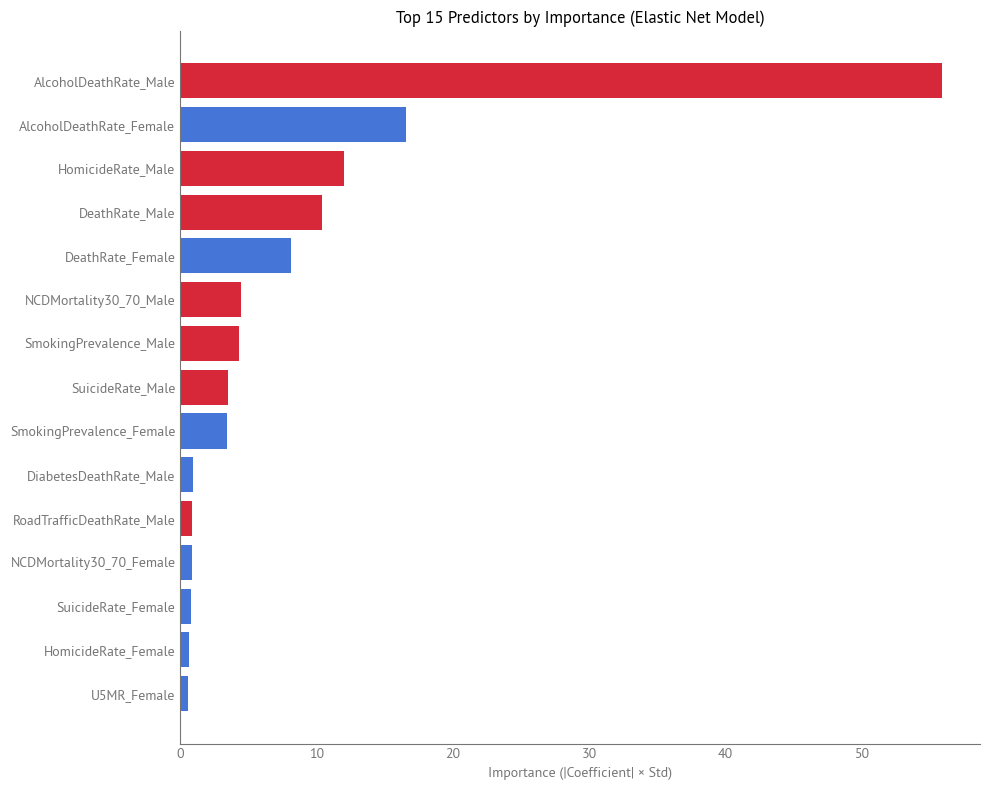

In [245]:
# Create bar chart of top predictors by importance
top_n = 15
top_importance = importance_df.head(top_n)

plt.figure(figsize=(10, 8))
colors = [AIBM_COLORS['crimson'] if x > 0 else AIBM_COLORS['blue'] 
          for x in top_importance['Coefficient']]
plt.barh(range(len(top_importance)), top_importance['Importance'], color=colors)
plt.yticks(range(len(top_importance)), top_importance['Predictor'])
plt.xlabel('Importance (|Coefficient| × Std)')
plt.title(f'Top {top_n} Predictors by Importance (Elastic Net Model)')
plt.gca().invert_yaxis()
decorate()
plt.tight_layout()

### Importance by Indicator

In [246]:
# Aggregate importance by indicator (sum of male and female importance)
indicator_importance = {}

for indicator in male_female_indicators:
    male_col = f'{indicator}_Male'
    female_col = f'{indicator}_Female'
    
    male_imp = importance_df[importance_df['Predictor'] == male_col]['Importance'].values
    female_imp = importance_df[importance_df['Predictor'] == female_col]['Importance'].values
    
    if len(male_imp) > 0 and len(female_imp) > 0:
        total_importance = male_imp[0] + female_imp[0]
        indicator_importance[indicator] = {
            'Male_Importance': male_imp[0],
            'Female_Importance': female_imp[0],
            'Total_Importance': total_importance
        }

# Add female-only indicators
for indicator in female_only_indicators:
    female_col = f'{indicator}_Female'
    female_imp = importance_df[importance_df['Predictor'] == female_col]['Importance'].values
    
    if len(female_imp) > 0:
        indicator_importance[indicator] = {
            'Male_Importance': np.nan,
            'Female_Importance': female_imp[0],
            'Total_Importance': female_imp[0]
        }

indicator_importance_df = pd.DataFrame(indicator_importance).T
indicator_importance_df = indicator_importance_df.sort_values('Total_Importance', ascending=False)
indicator_importance_df

,Male_Importance,Female_Importance,Total_Importance
AlcoholDeathRate,55.846190,16.546199,72.392389
HomicideRate,12.010194,0.614281,12.624475
SmokingPrevalence,4.281662,3.435495,7.717157
NCDMortality30_70,4.485391,0.852128,5.337519
SuicideRate,3.535891,0.773297,4.309188
DiabetesDeathRate,0.968093,0.405229,1.373322
RoadTrafficDeathRate,0.898598,0.000000,0.898598
U5MR,0.032486,0.537742,0.570228
PoisoningRate,0.017888,0.000207,0.018095
MaternalMortalityRatio,NaN,0.000000,0.000000


### Visualize Indicator Importance

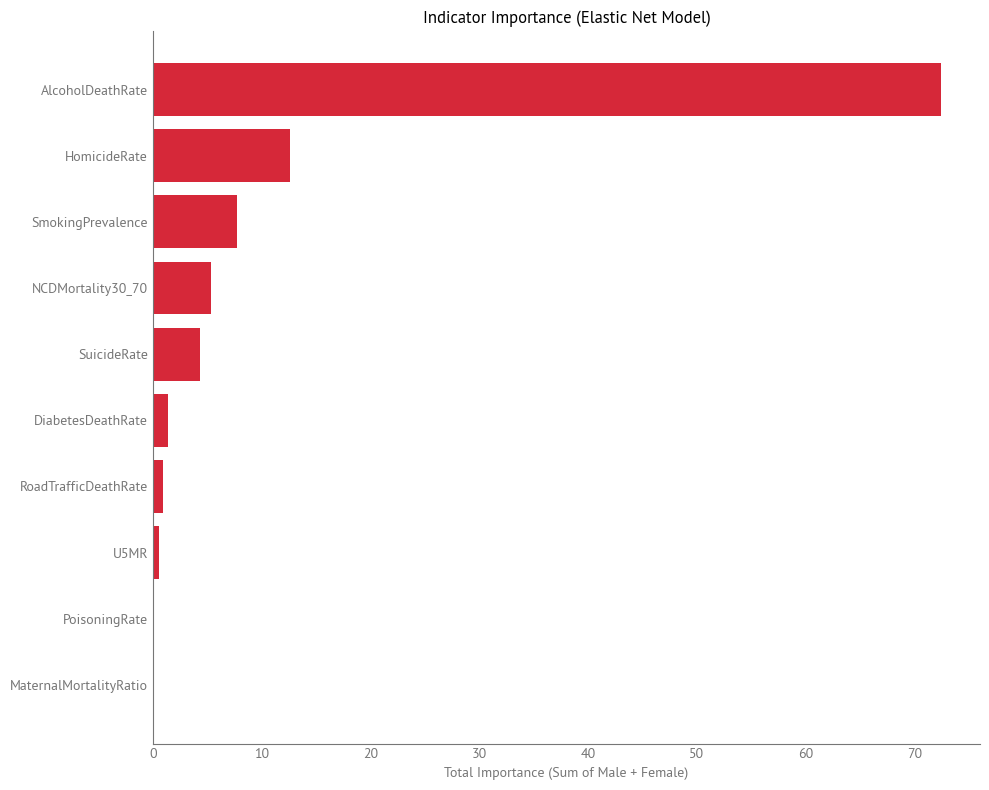

In [247]:
# Bar chart of indicator-level importance
plt.figure(figsize=(10, 8))
colors_bar = [AIBM_COLORS['crimson'] for _ in range(len(indicator_importance_df))]
plt.barh(range(len(indicator_importance_df)), indicator_importance_df['Total_Importance'], 
         color=colors_bar)
plt.yticks(range(len(indicator_importance_df)), indicator_importance_df.index)
plt.xlabel('Total Importance (Sum of Male + Female)')
plt.title('Indicator Importance (Elastic Net Model)')
plt.gca().invert_yaxis()
decorate()
plt.tight_layout()